# Detecção da Ionosfera Utilizando Rede Neural Adaline / Ionosphere Detection using Adaline Neural Network

- **A1:** [João Pedro Fernandes de Aquino](https://github.com/Joaof14)
- **A2:** [Anderson Carlos da Silva Morais](https://github.com/AndersonCSM)








## Contextualização do Projeto (PT-BR) / Project Context (EN-US)

<details>
  <summary><h3 style="display: inline;">PT-BR</h3></summary>

O monitoramento contínuo da ionosfera é crucial para a confiabilidade de sistemas de telecomunicações, navegação GPS e para a previsão de tempestades geomagnéticas. Radares de alta frequência (HF) emitem pulsos e analisam os sinais refletidos para verificar a existência de estruturas eletrônicas coerentes na ionosfera. O Brasil ocupa posição estratégica e desafiadora, situado sobre a Anomalia de Ionização Equatorial, onde a ionosfera apresenta irregularidades intensas e fenômenos como as bolhas de plasma – fatores que afetam diretamente o desempenho de sinais de comunicação e posicionamento. Este projeto utiliza o dataset Ionosphere (UCI Machine Learning Repository), com 351 retornos de radar e 34 atributos contínuos provenientes de autocorrelação de pulsos. O objetivo é construir uma rede Adaline para classificar automaticamente os retornos em "good" (estrutura ionosférica detectada, +1) ou "bad" (ausência de estrutura coerente, −1), contribuindo para sistemas de alerta e diagnóstico da ionosfera.

</details>

<details>
  <summary><h3 style="display: inline;">EN-US</h3></summary>

Continuous monitoring of the ionosphere is crucial for the reliability of telecommunications systems, GPS navigation, and the forecasting of geomagnetic storms. High-frequency (HF) radars transmit pulses and analyze the reflected signals to detect coherent electronic structures in the ionosphere. Brazil occupies a strategic and challenging position, situated over the Equatorial Ionization Anomaly, where the ionosphere exhibits intense irregularities and phenomena such as plasma bubbles—factors that directly affect the performance of communication and positioning signals. This project uses the Ionosphere dataset (UCI Machine Learning Repository), with 351 radar returns and 34 continuous attributes derived from pulse autocorrelation. The goal is to build an Adaline network to automatically classify the returns as "good" (ionospheric structure detected, +1) or "bad" (absence of coherent structure, −1), contributing to ionospheric warning and diagnostic systems.

</details>

## Etapas do Projeto (PT-BR)  /  Project Steps (EN-US)

<details>
  <summary><h3 style="display: inline;">PT-BR</h3></summary>

1. Exploração e verificação da qualidade dos dados;
2. Validação das premissas do modelo;
3. Seleção de atributos;
4. Normalização/padronização e divisão dos dados;
5. Ajuste do modelo (treinamento);
6. Avaliação;
7. Relatório.

</details>

<details>
  <summary><h3 style="display: inline;">EN-US</h3></summary>

1. Data exploration and quality checks;
2. Validate modeling assumptions;
3. Feature selection;
4. Normalization or scaling and data split;
5. Model fitting (adjustment);
6. Assessment;
7. Report.

</details>

## Etapa 1 – Exploração e Verificação da Qualidade dos Dados (PT-BR) / Step 1 – Data Exploration and Quality Checks (EN-US)

<details>
  <summary><h3 style="display: inline;">Detalhes (PT-BR)</h3></summary>

**1. Obter e inspecionar o dataset**
- Carregar o dataset diretamente do repositório UCI (`ucimlrepo` ou `ionosphere.data`).
- Criar um DataFrame com as 34 features e a coluna `class`.
- Verificar com `df.info()`: 351 instâncias, 35 colunas, tipos numéricos (`float64`/`int64`) e target categórico (`object`).
- Usar `df.head()` e `df.describe()` para um resumo estatístico.

**2. Recodificar o target**
- Target original: `'g'` (good) e `'b'` (bad).
- Converter para bipolar: `+1` (good) e `−1` (bad).
- Confirmar as quantidades: 225 good e 126 bad.

**3. Verificar a qualidade dos dados**
- **Valores ausentes:** `df.isnull().sum()` – tipicamente nenhum. Se houver, imputar ou remover.
- **Atributos constantes:** Calcular o desvio padrão; remover qualquer preditor com `std ≈ 0`.
- **Duplicatas:** `df.duplicated().sum()` e remoção, se existirem.

**4. Análise univariada**
- Plotar histogramas para cada um dos 34 atributos.
- Plotar boxplots para detectar outliers severos.

**5. Análise bivariada / multivariada**
- Matriz de correlação de Pearson e mapa de calor.
- Correlação preditor–target: gráfico de barras.
- Boxplots por classe (good vs bad) para as features mais correlacionadas.

**6. Resumo**
- Resumo da qualidade (missings, constantes, outliers).
- Lista de atributos removidos (se houver).
- Matriz de correlação comentada.
- Histogramas e boxplots para o relatório.
</details>

<details>
  <summary><h3 style="display: inline;">Details (EN-US)</h3></summary>

**1. Obtain and inspect the dataset**
- Load the dataset from the UCI repository (`ucimlrepo` or `ionosphere.data`).
- Create a DataFrame with 34 features and the `class` column.
- Check with `df.info()`: 351 instances, 35 columns, numeric predictors, categorical target.
- Use `df.head()` and `df.describe()` for a statistical summary.

**2. Recode the target**
- Original target: `'g'` (good) and `'b'` (bad).
- Convert to bipolar: `+1` for good, `−1` for bad.
- Confirm counts: 225 good, 126 bad.

**3. Data quality checks**
- **Missing values:** `df.isnull().sum()` – typically none. Handle if any.
- **Constant features:** Remove predictors with `std ≈ 0`.
- **Duplicates:** `df.duplicated().sum()` and removal if needed.

**4. Univariate analysis**
- Histograms for all 34 attributes.
- Boxplots to detect severe outliers.

**5. Bivariate / multivariate analysis**
- Pearson correlation matrix and heatmap.
- Predictor–target correlation bar chart.
- Boxplots by class for the most correlated features.

**6. Summary**
- Quality summary.
- List of removed attributes (if any).
- Annotated correlation matrix.
- Histograms and boxplots saved for the report.
</details>

<br>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# Configurações de visualização
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
# sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

### 1.1 Obter e inspecionar o dataset / Obtain and inspect the dataset

In [3]:
ionosphere = fetch_ucirepo(id=52)

##Obter as features e os targets
X = ionosphere.data.features
y_df = ionosphere.data.targets

X.info()

<class 'pandas.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 34 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Attribute1   351 non-null    int64  
 1   Attribute2   351 non-null    int64  
 2   Attribute3   351 non-null    float64
 3   Attribute4   351 non-null    float64
 4   Attribute5   351 non-null    float64
 5   Attribute6   351 non-null    float64
 6   Attribute7   351 non-null    float64
 7   Attribute8   351 non-null    float64
 8   Attribute9   351 non-null    float64
 9   Attribute10  351 non-null    float64
 10  Attribute11  351 non-null    float64
 11  Attribute12  351 non-null    float64
 12  Attribute13  351 non-null    float64
 13  Attribute14  351 non-null    float64
 14  Attribute15  351 non-null    float64
 15  Attribute16  351 non-null    float64
 16  Attribute17  351 non-null    float64
 17  Attribute18  351 non-null    float64
 18  Attribute19  351 non-null    float64
 19  Attribute20  351 no

In [4]:
# Metadados relevantes 
print('Missing values:', ionosphere.metadata['has_missing_values'])
print('Feature types:', ionosphere.metadata['feature_types'])

Missing values: no
Feature types: ['Integer', 'Real']


In [5]:
# Descrução das Features
X.describe()

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute25,Attribute26,Attribute27,Attribute28,Attribute29,Attribute30,Attribute31,Attribute32,Attribute33,Attribute34
count,351.000000,351.0,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,...,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000,351.000000
mean,0.891738,0.0,0.641342,0.044372,0.601068,0.115889,0.550095,0.119360,0.511848,0.181345,...,0.396135,-0.071187,0.541641,-0.069538,0.378445,-0.027907,0.352514,-0.003794,0.349364,0.014480
std,0.311155,0.0,0.497708,0.441435,0.519862,0.460810,0.492654,0.520750,0.507066,0.483851,...,0.578451,0.508495,0.516205,0.550025,0.575886,0.507974,0.571483,0.513574,0.522663,0.468337
min,0.000000,0.0,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,1.000000,0.0,0.472135,-0.064735,0.412660,-0.024795,0.211310,-0.054840,0.087110,-0.048075,...,0.000000,-0.332390,0.286435,-0.443165,0.000000,-0.236885,0.000000,-0.242595,0.000000,-0.165350
50%,1.000000,0.0,0.871110,0.016310,0.809200,0.022800,0.728730,0.014710,0.684210,0.018290,...,0.553890,-0.015050,0.708240,-0.017690,0.496640,0.000000,0.442770,0.000000,0.409560,0.000000
75%,1.000000,0.0,1.000000,0.194185,1.000000,0.334655,0.969240,0.445675,0.953240,0.534195,...,0.905240,0.156765,0.999945,0.153535,0.883465,0.154075,0.857620,0.200120,0.813765,0.171660
max,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
### Verificar Frequência de cada classe
y_df['Class'].value_counts()

Class
g    225
b    126
Name: count, dtype: int64

### 1.2 Recodificar o Target / Recode the target

In [7]:
y = y_df['Class'].map({'g': 1, 'b': -1}).values
y

array([ 1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1,
       -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,
        1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1,
       -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,
        1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1,
       -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1,  1, -1,  1, -1,  1,
       -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,
        1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1,
       -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,
        1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1,
       -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,
        1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1,
       -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,  1, -1,
        1, -1,  1, -1,  1

### 1.3 Verificar a Qualidade dos dados / Data quality checks

In [8]:
# Verificar se existem valores ausentes
assert X.isnull().sum().sum() == 0, "Missings encontrados"

In [9]:
# Verificaqr se há valores constantes
col_const = X.columns[X.std() < 1e-10]
if len(col_const):
    X = X.drop(columns=col_const)

In [10]:
# Verificar se há valores duplicados e remove se for o caso (tanto x quanto y)
dup = X.duplicated()
if dup.any():
    X = X[~dup].reset_index(drop=True)
    y = y[~dup.values]

### 1.4 Análise univariada / Univariate analysis

In [11]:
def plotUnivariate(inf, sup):
    cols = X.columns[inf:sup]
    fig, ax = plt.subplots(2, sup-inf, figsize=(25, 12))

    for i, c in enumerate(cols):
        ax[0, i].hist(X[c], bins=20, color='steelblue', alpha=0.7)
        ax[0, i].set_title(c, fontsize=8)
        ax[1, i].boxplot(X[c], patch_artist=True, boxprops=dict(facecolor='lightblue'))
        ax[1, i].set_title(c, fontsize=8)

    plt.tight_layout()
    plt.show()

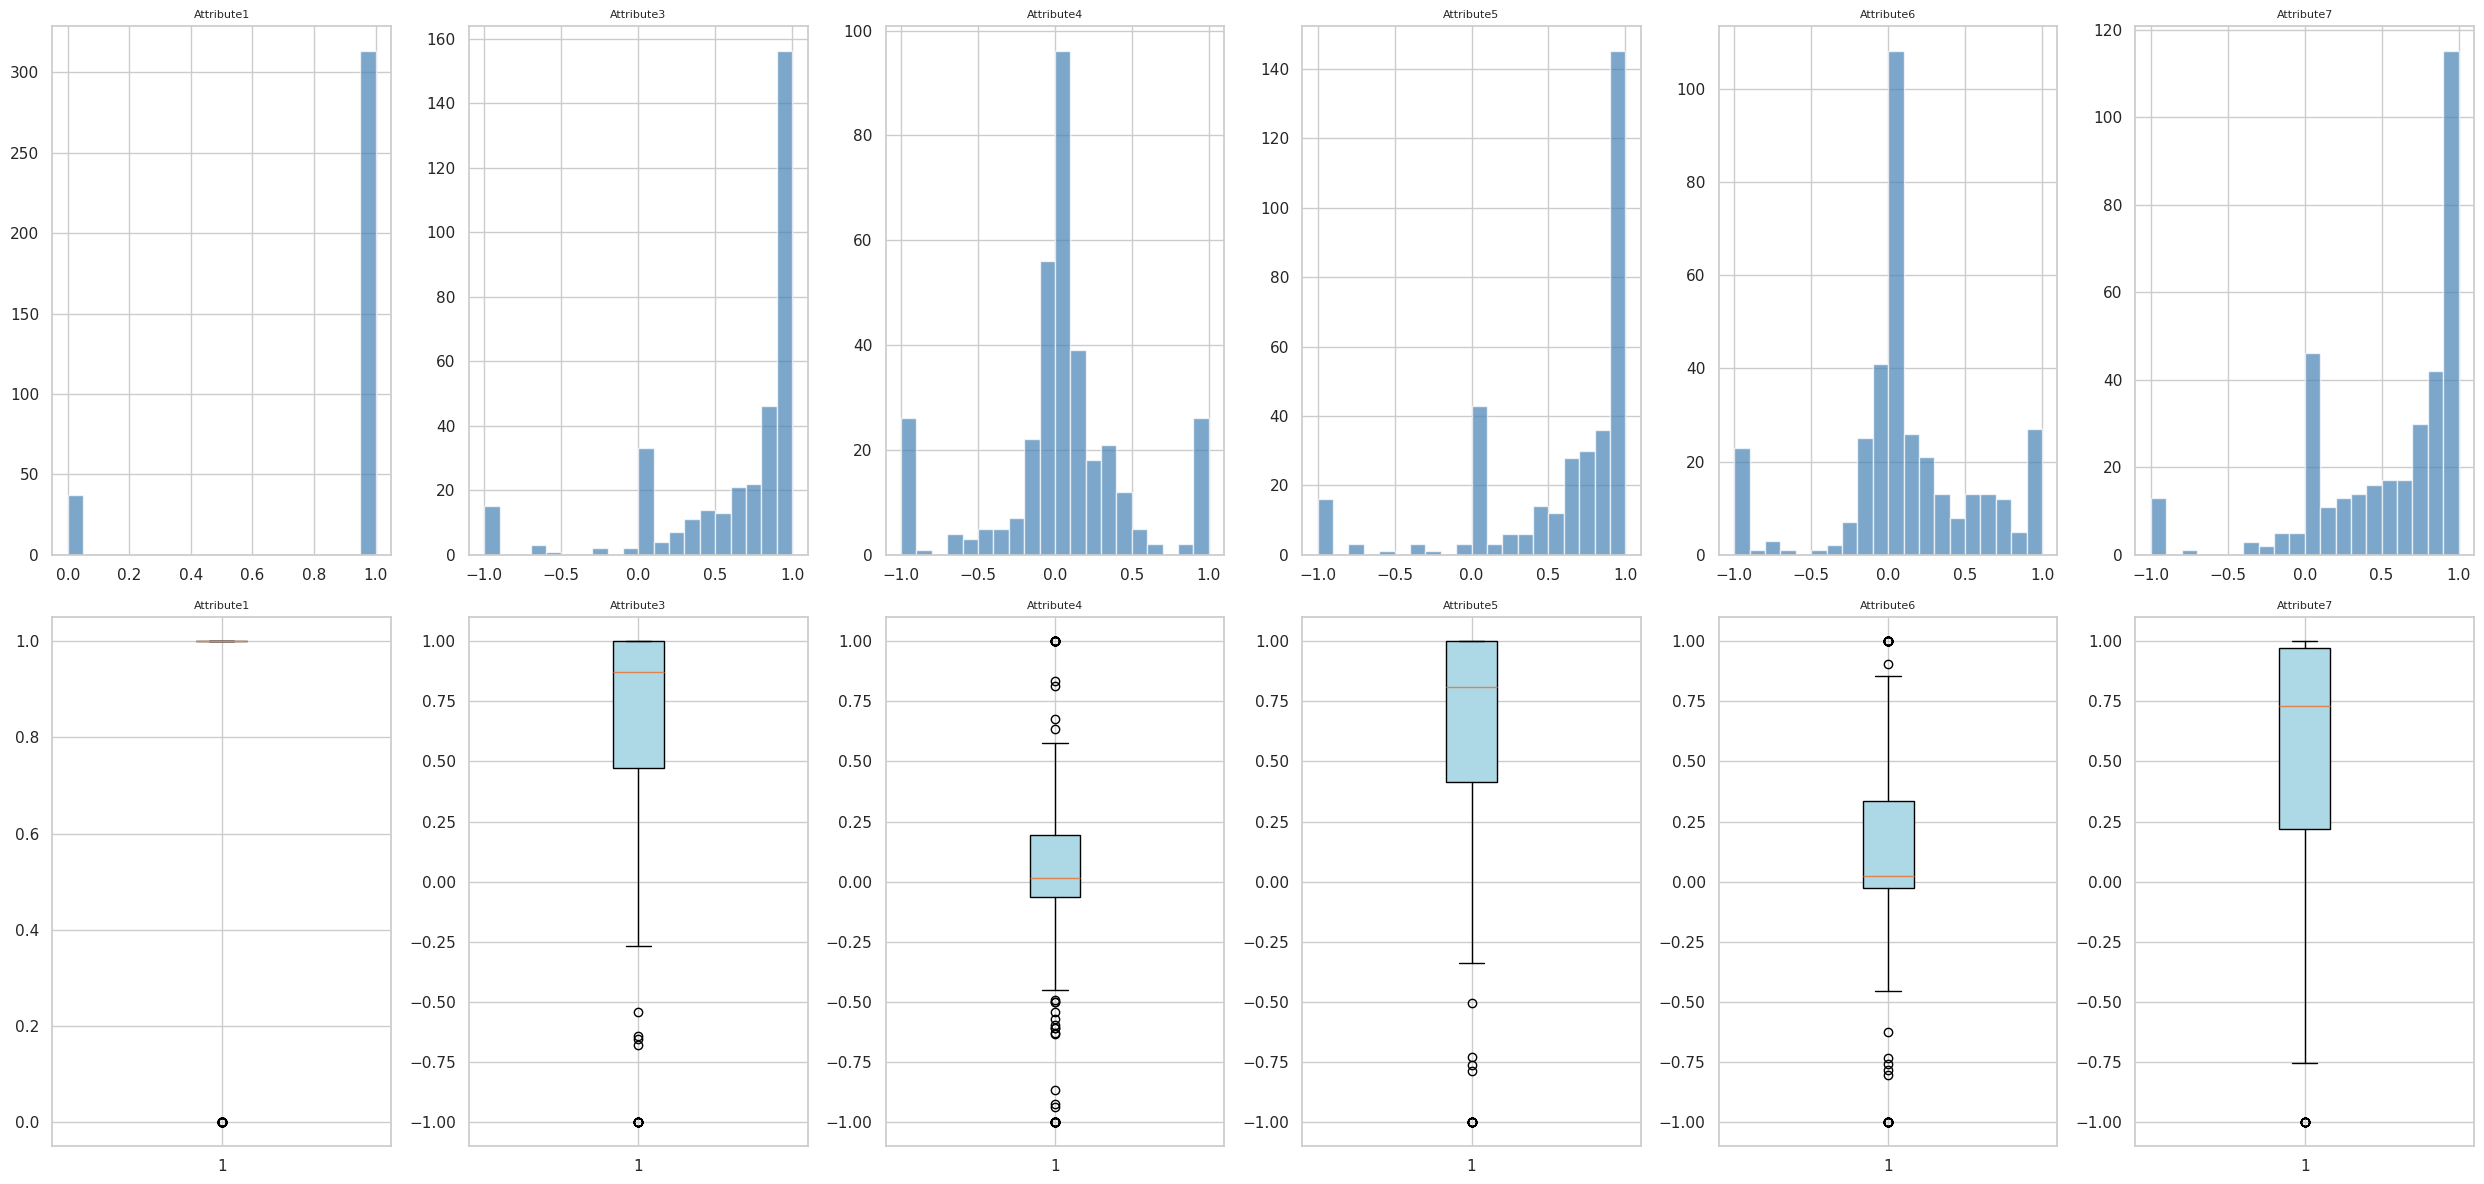

In [12]:
# Features 1-6
plotUnivariate(0,6)

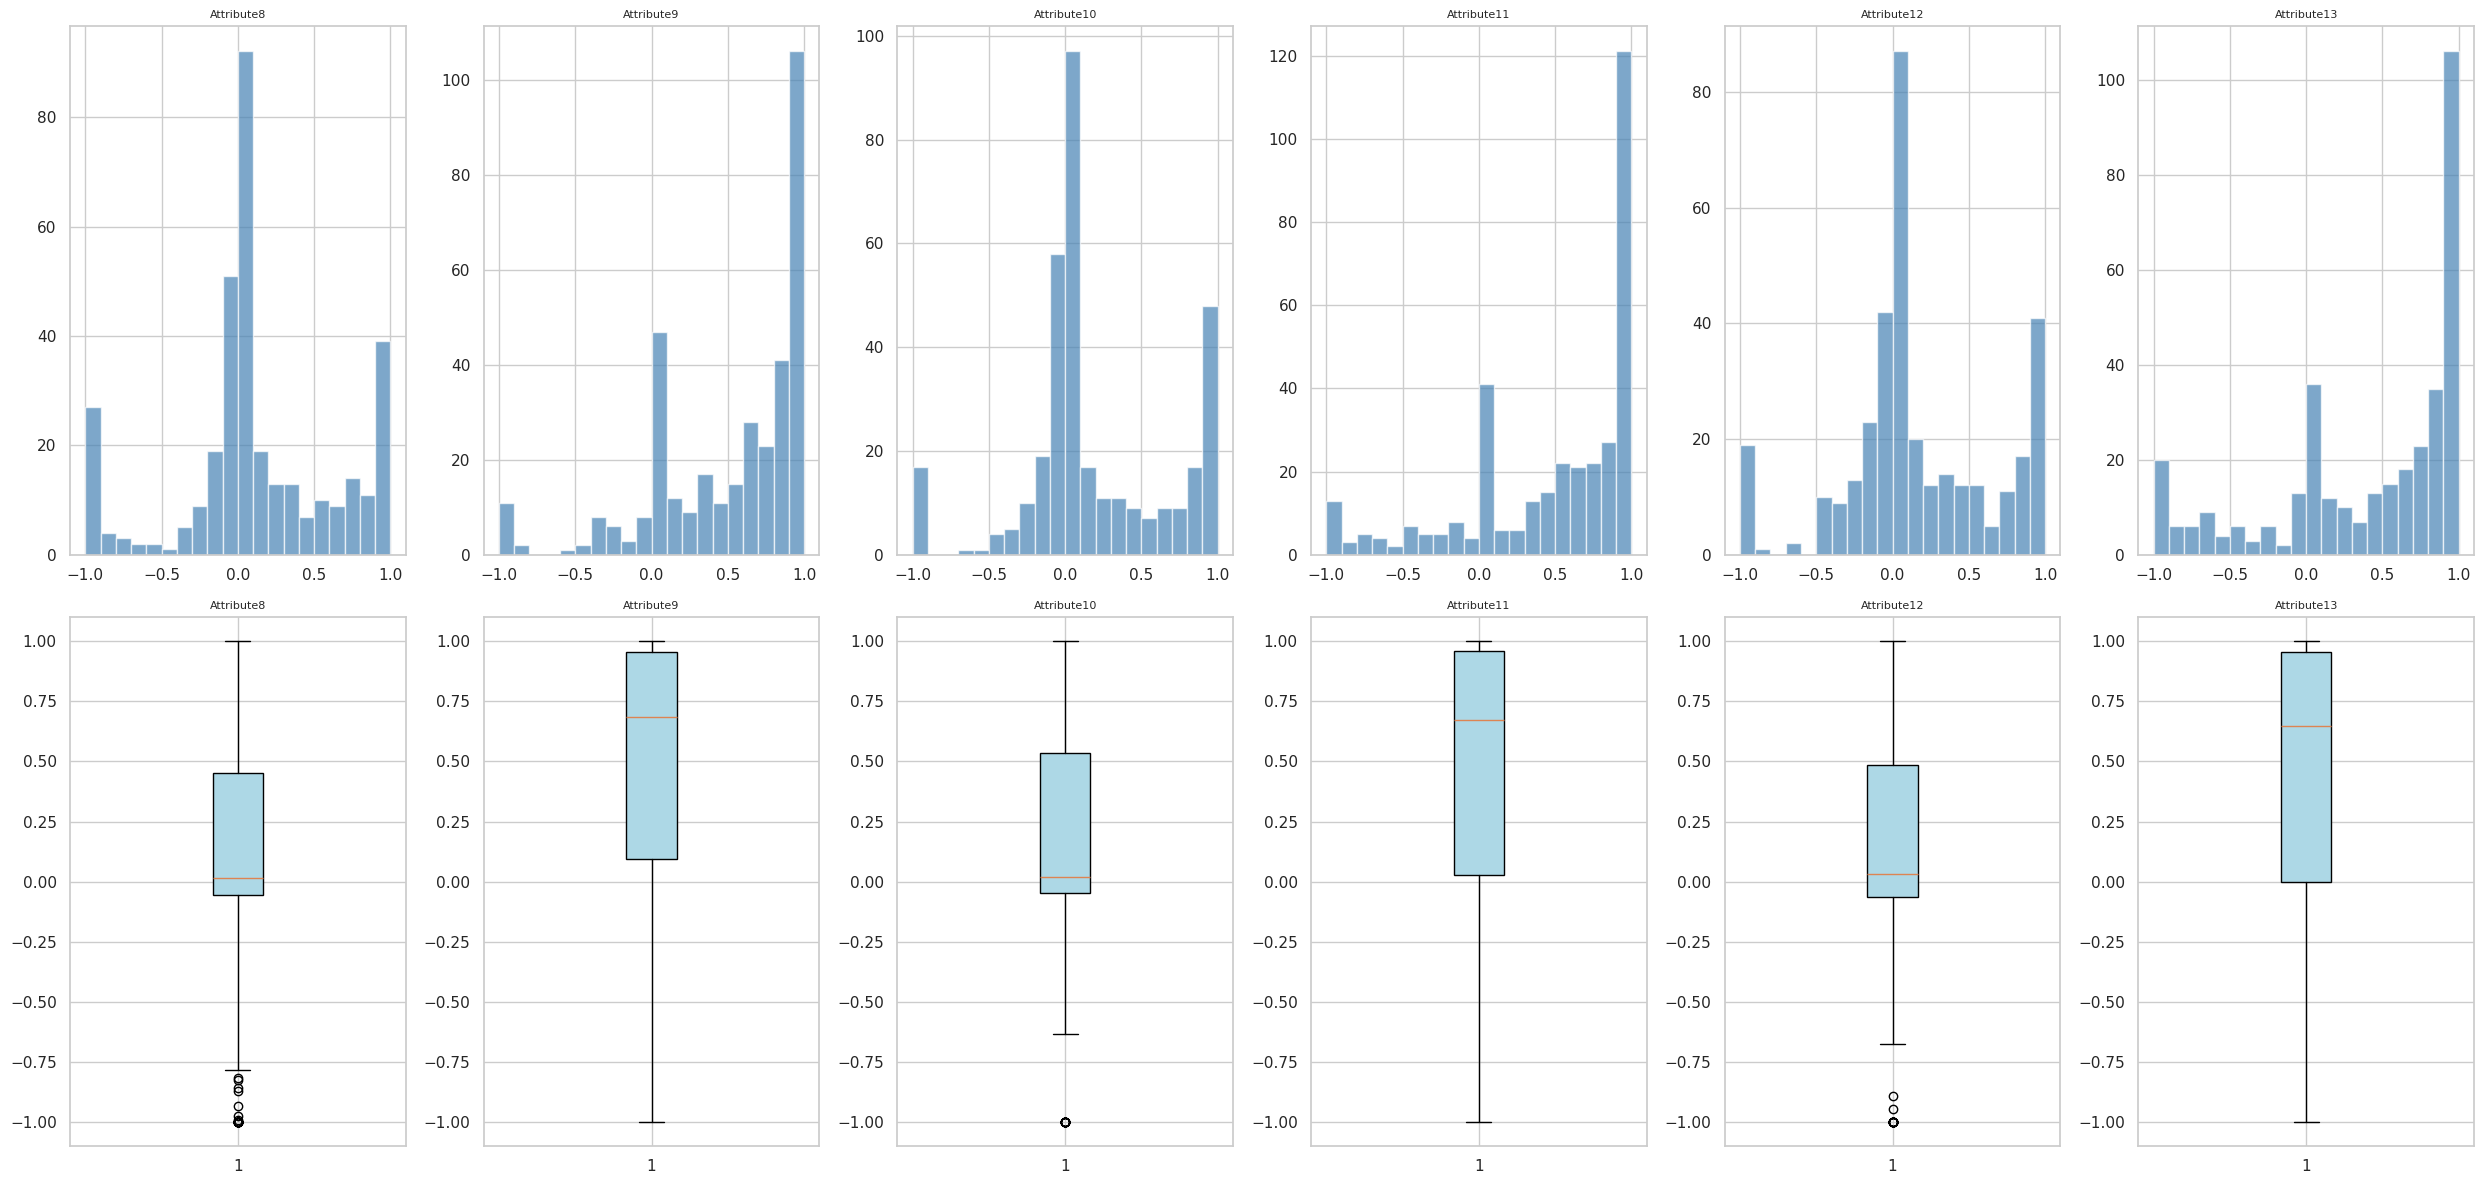

In [13]:
# Features 7-12
plotUnivariate(6,12)

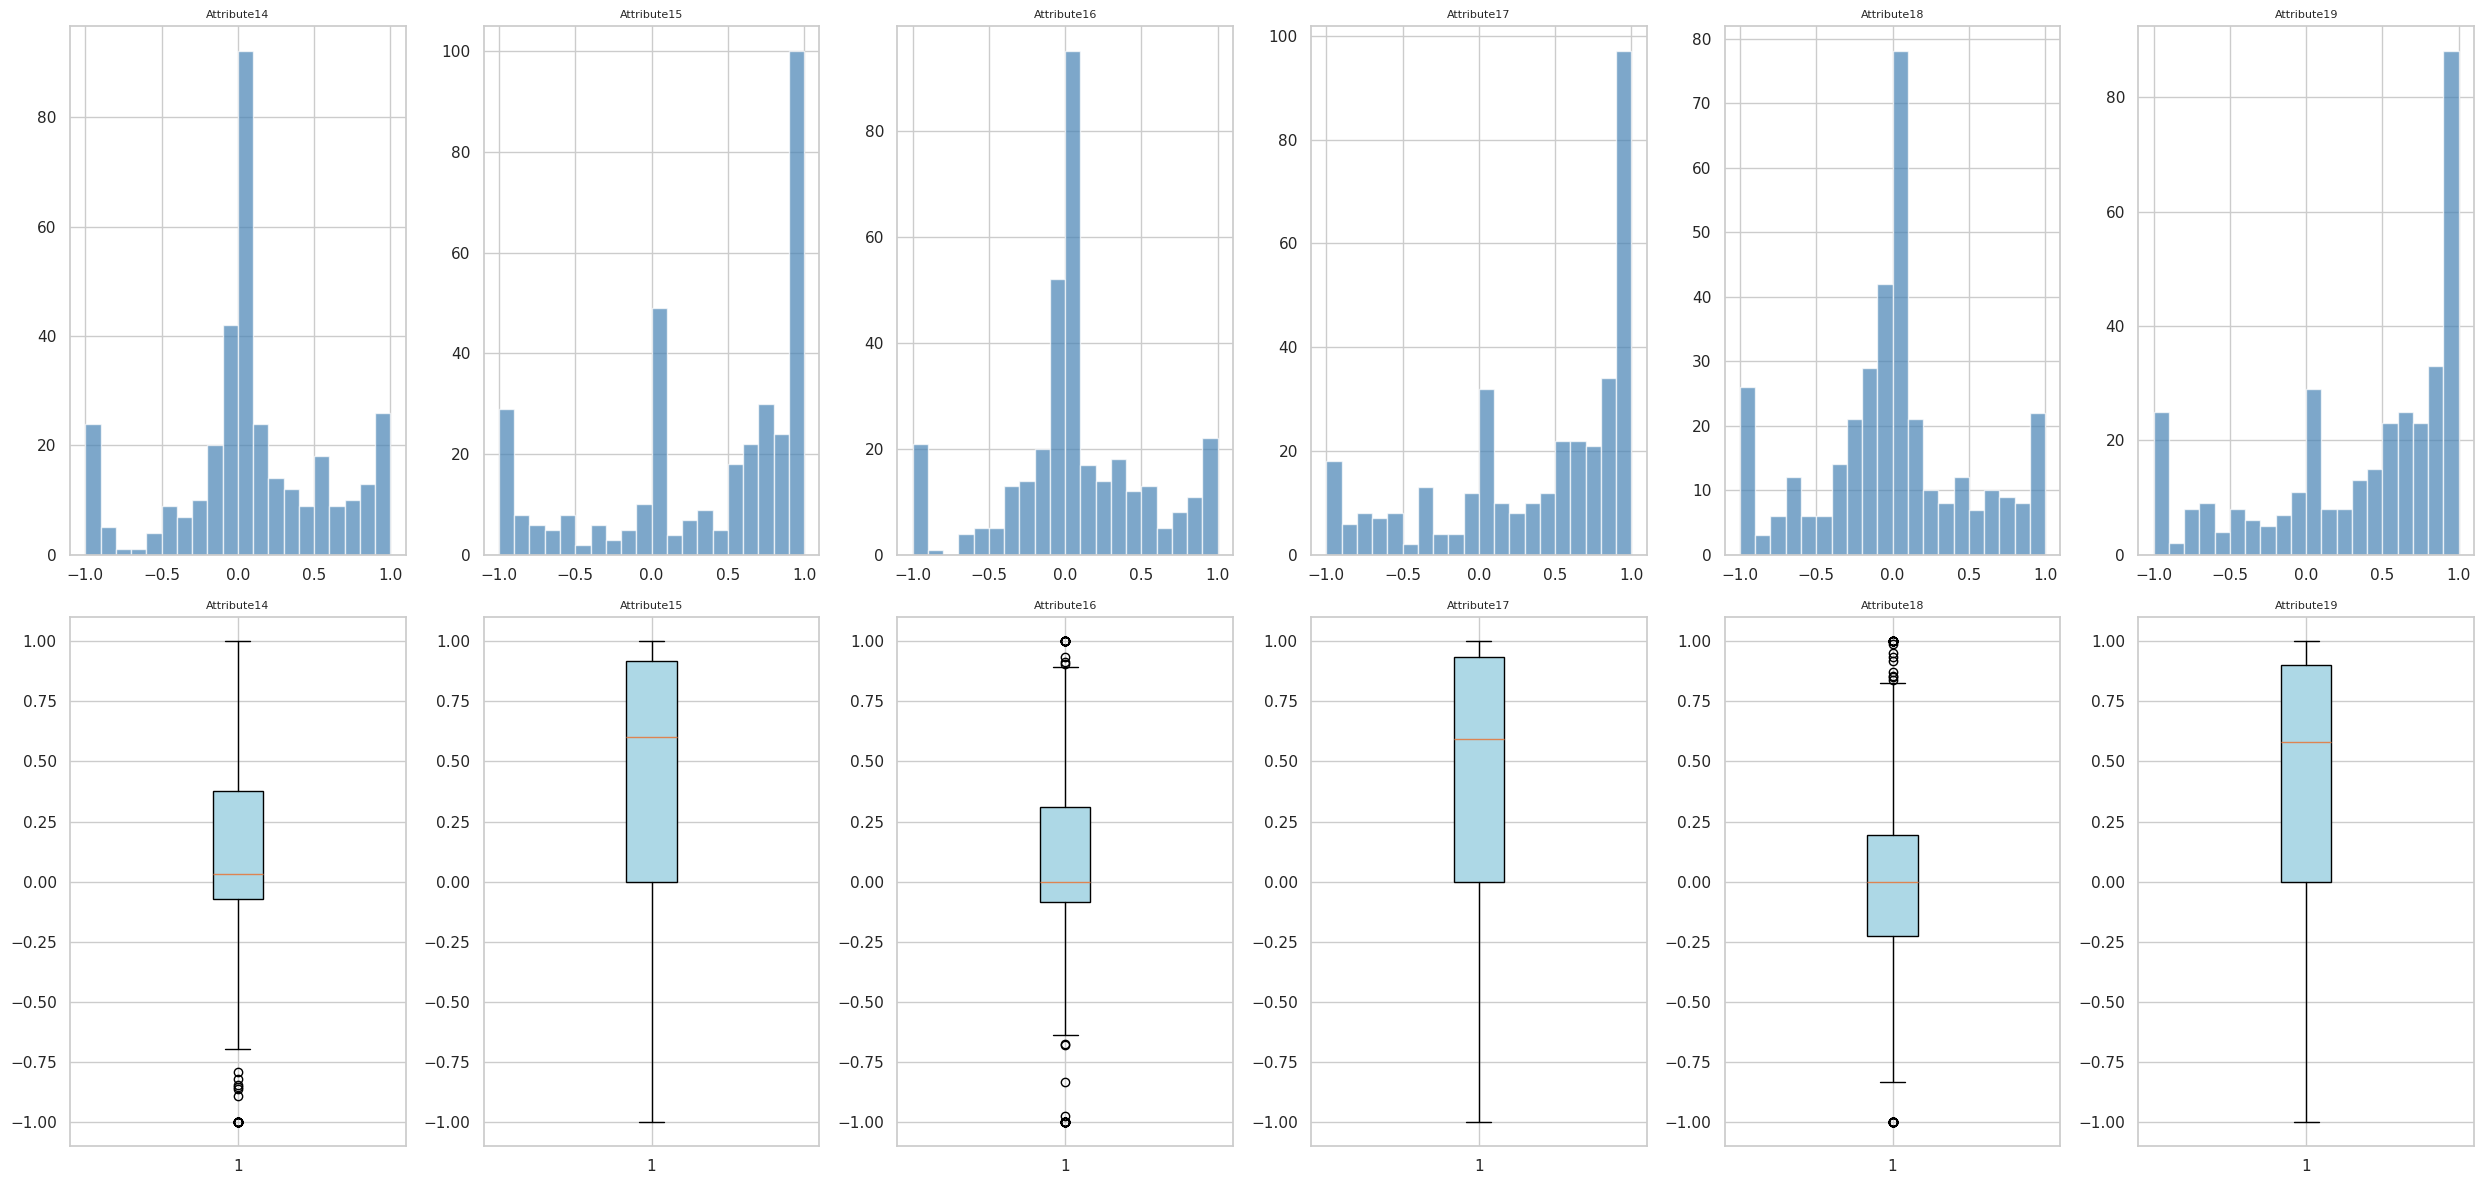

In [14]:
# Features 13-18
plotUnivariate(12,18)

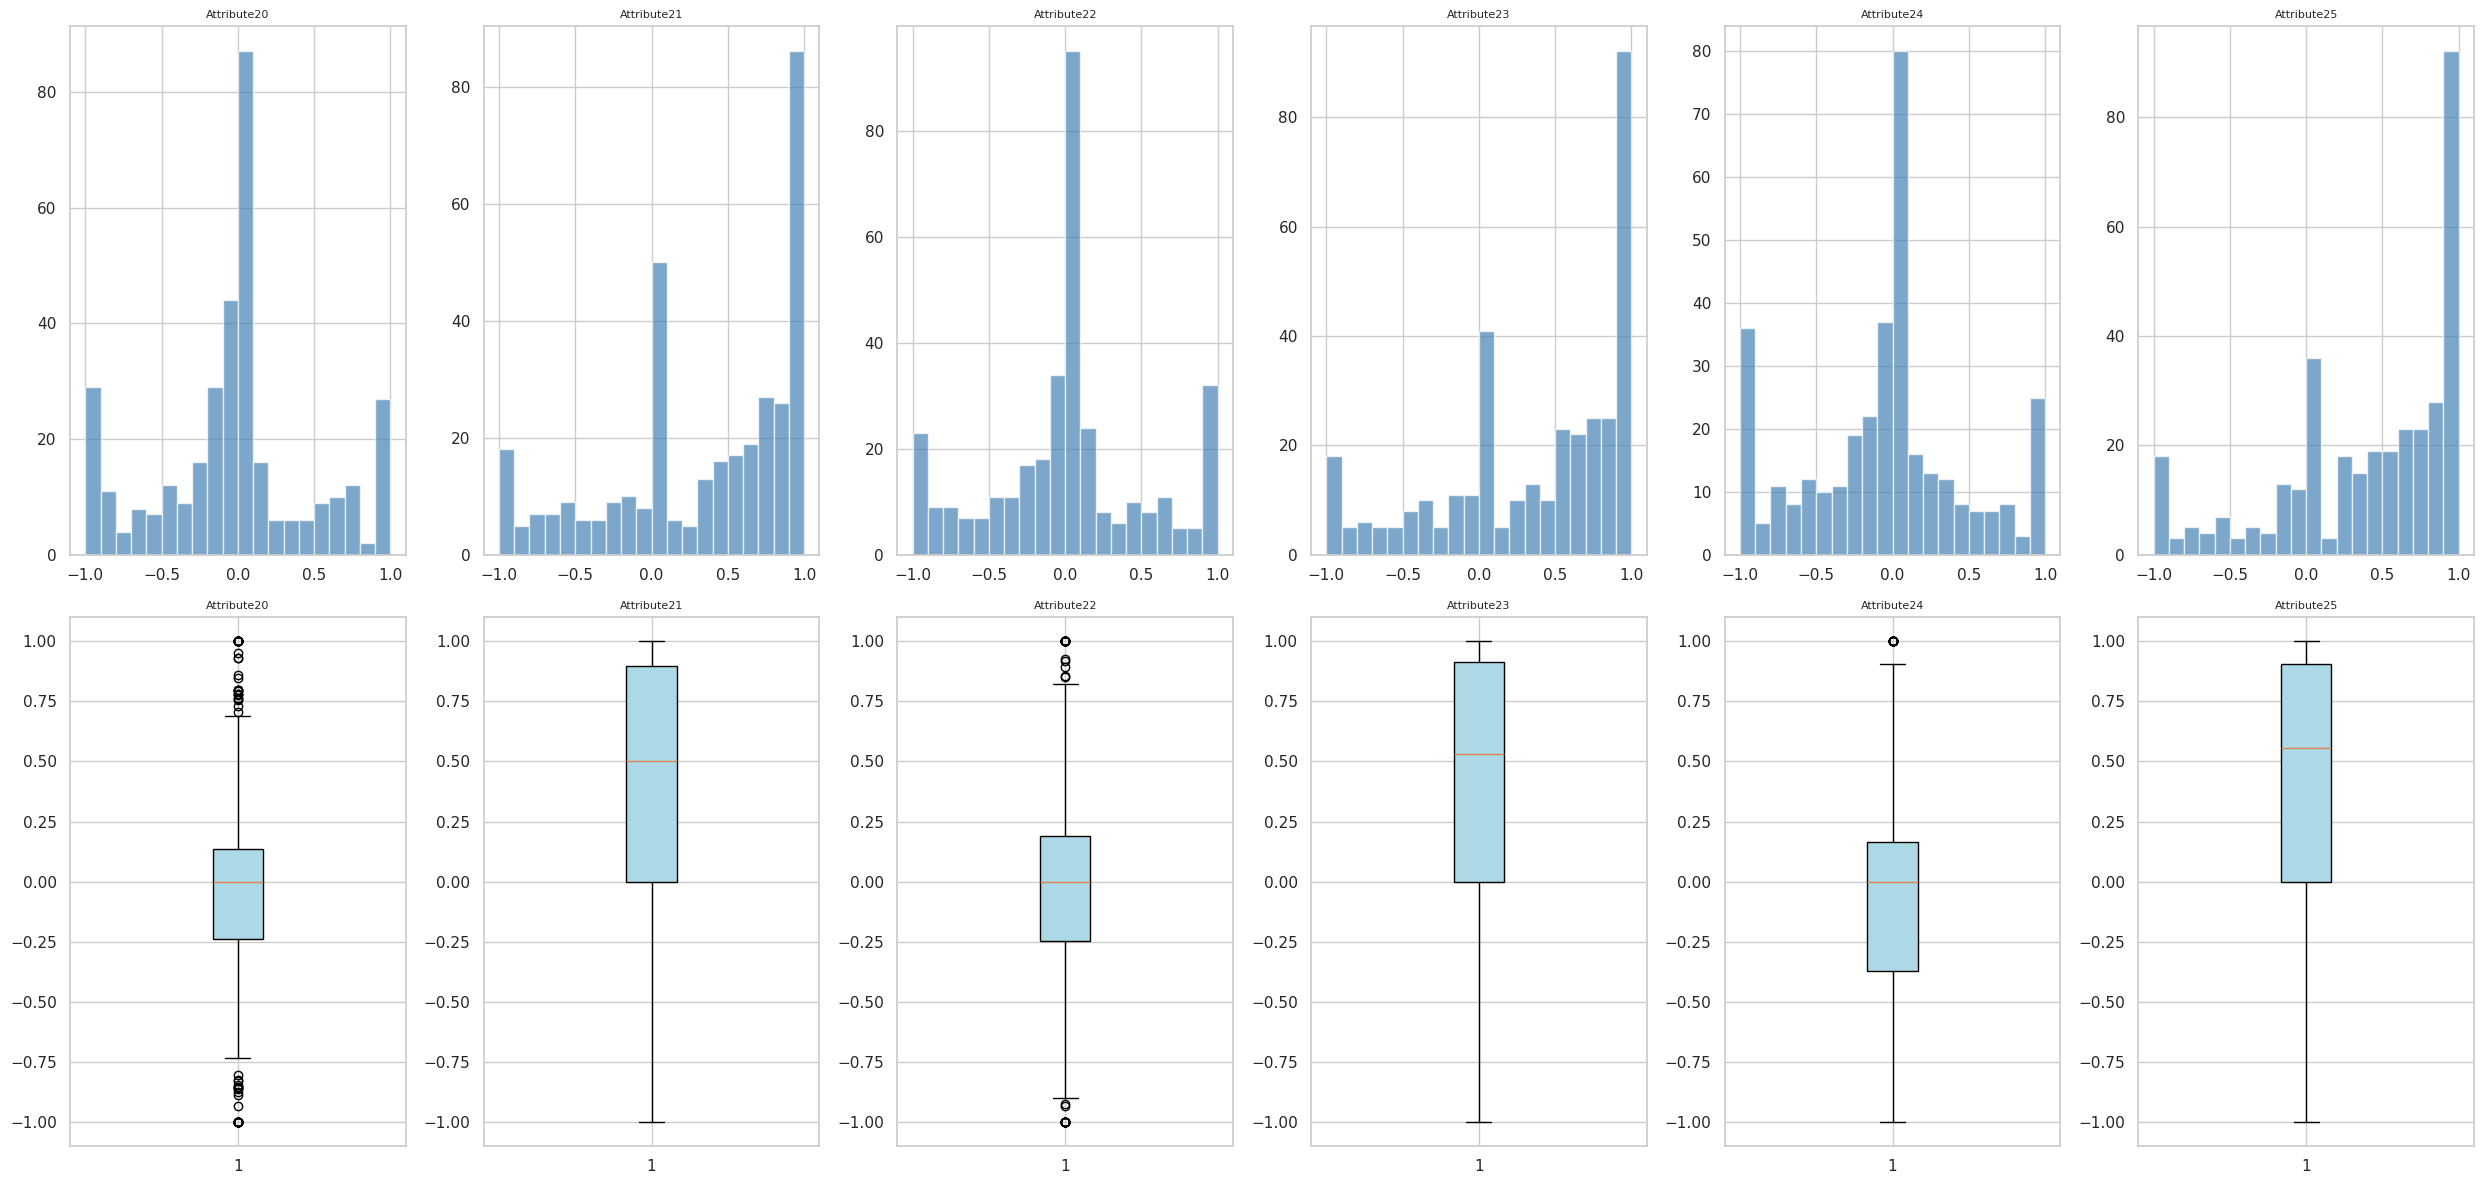

In [15]:
# Features 19-24
plotUnivariate(18,24)

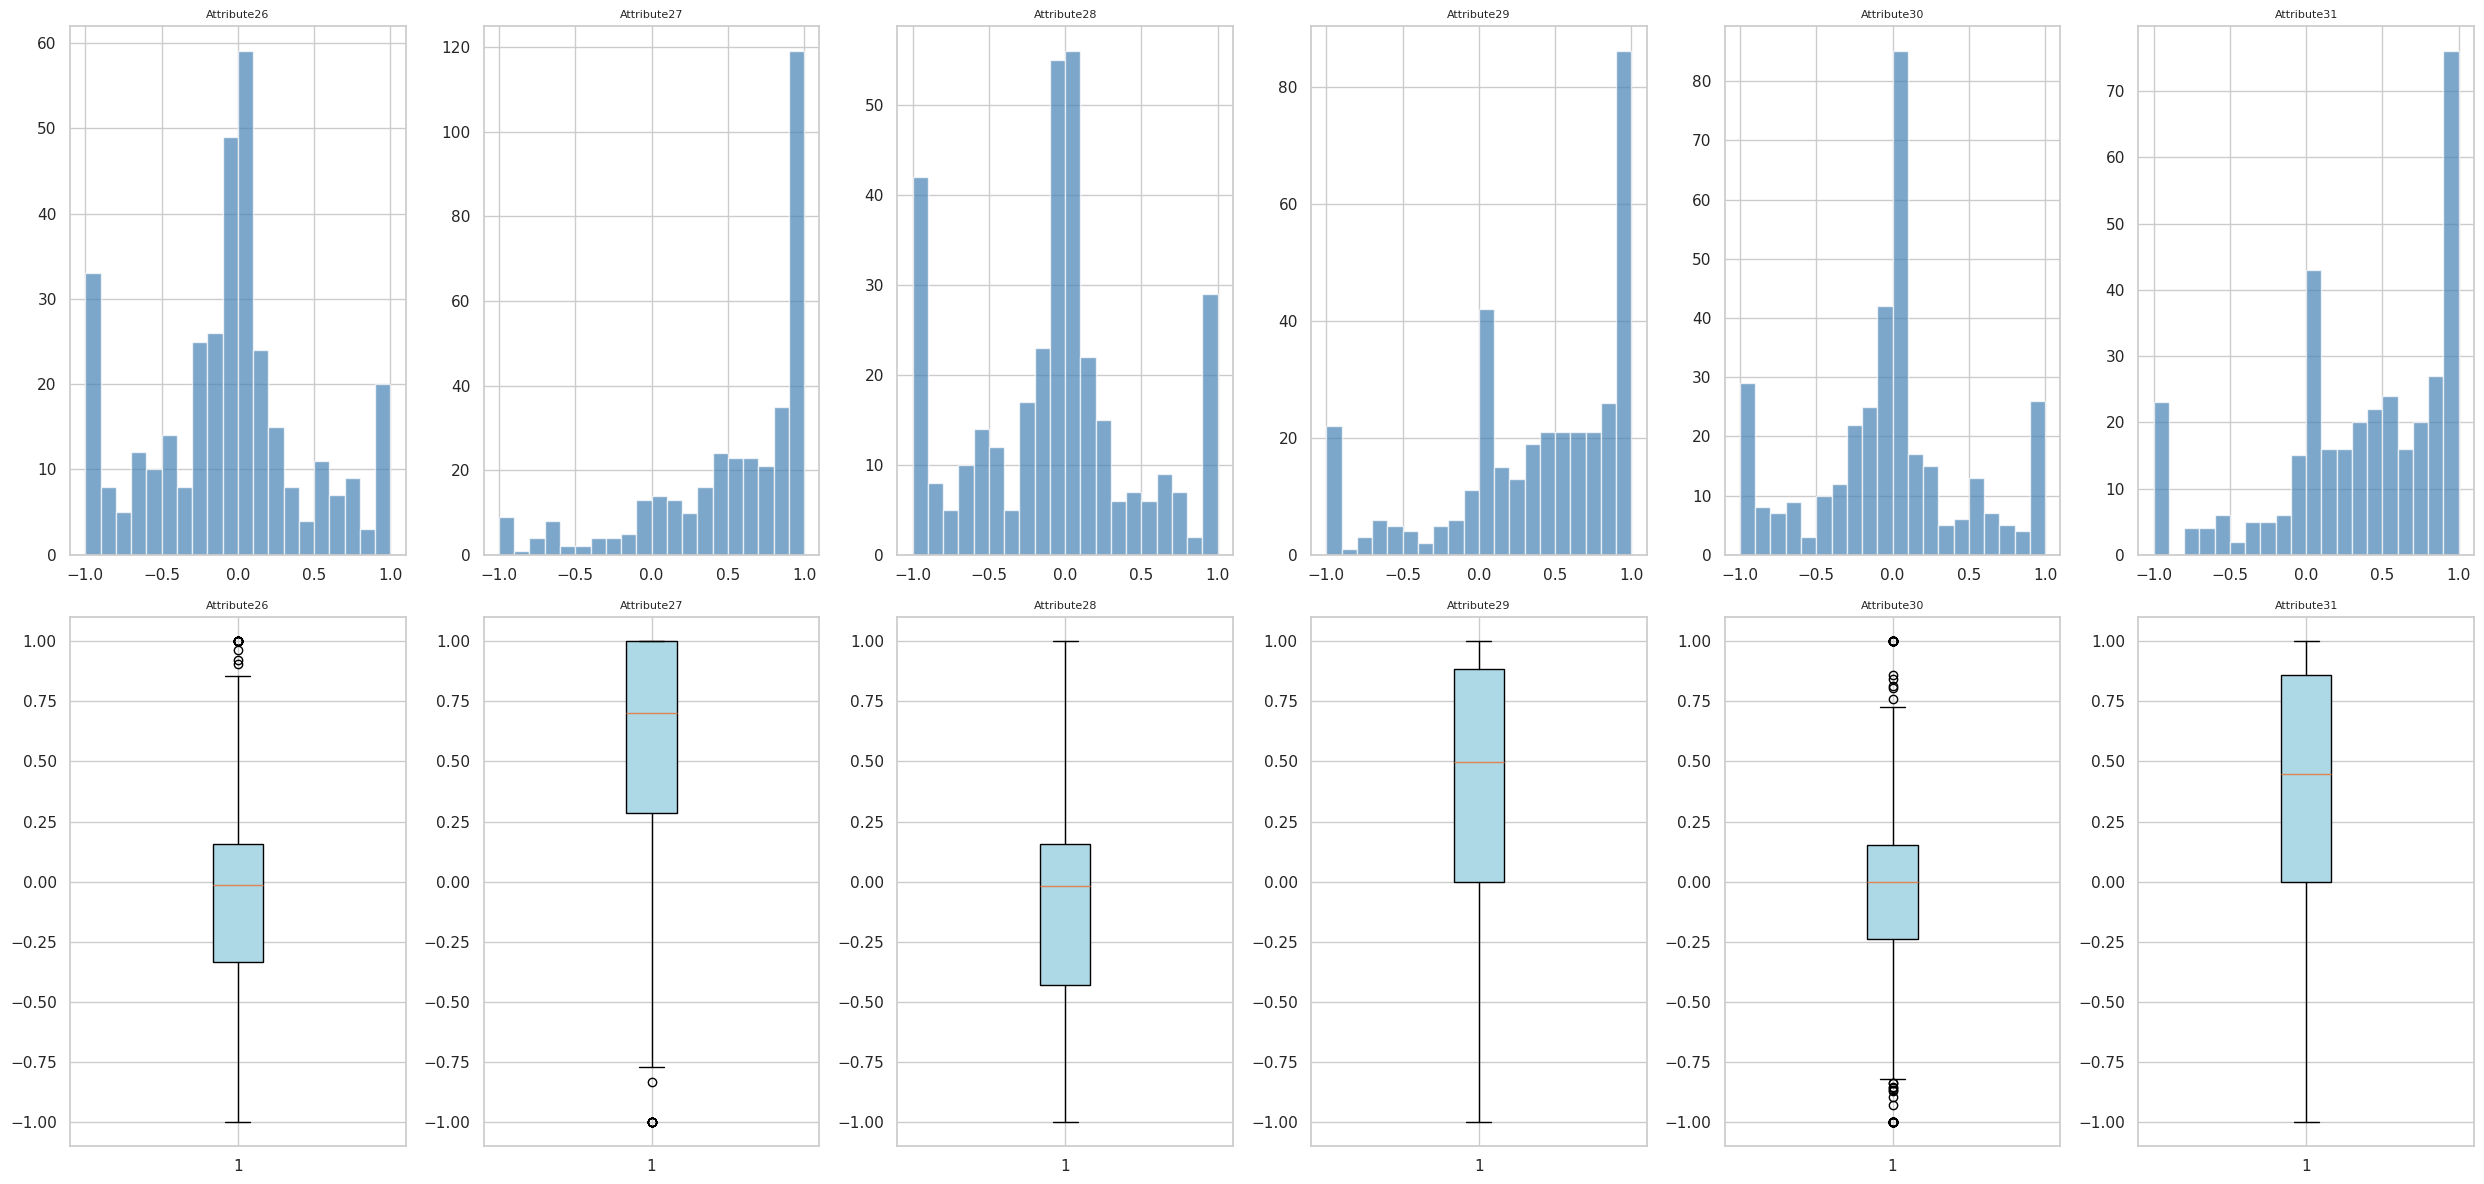

In [16]:
# Features 25-30
plotUnivariate(24,30)

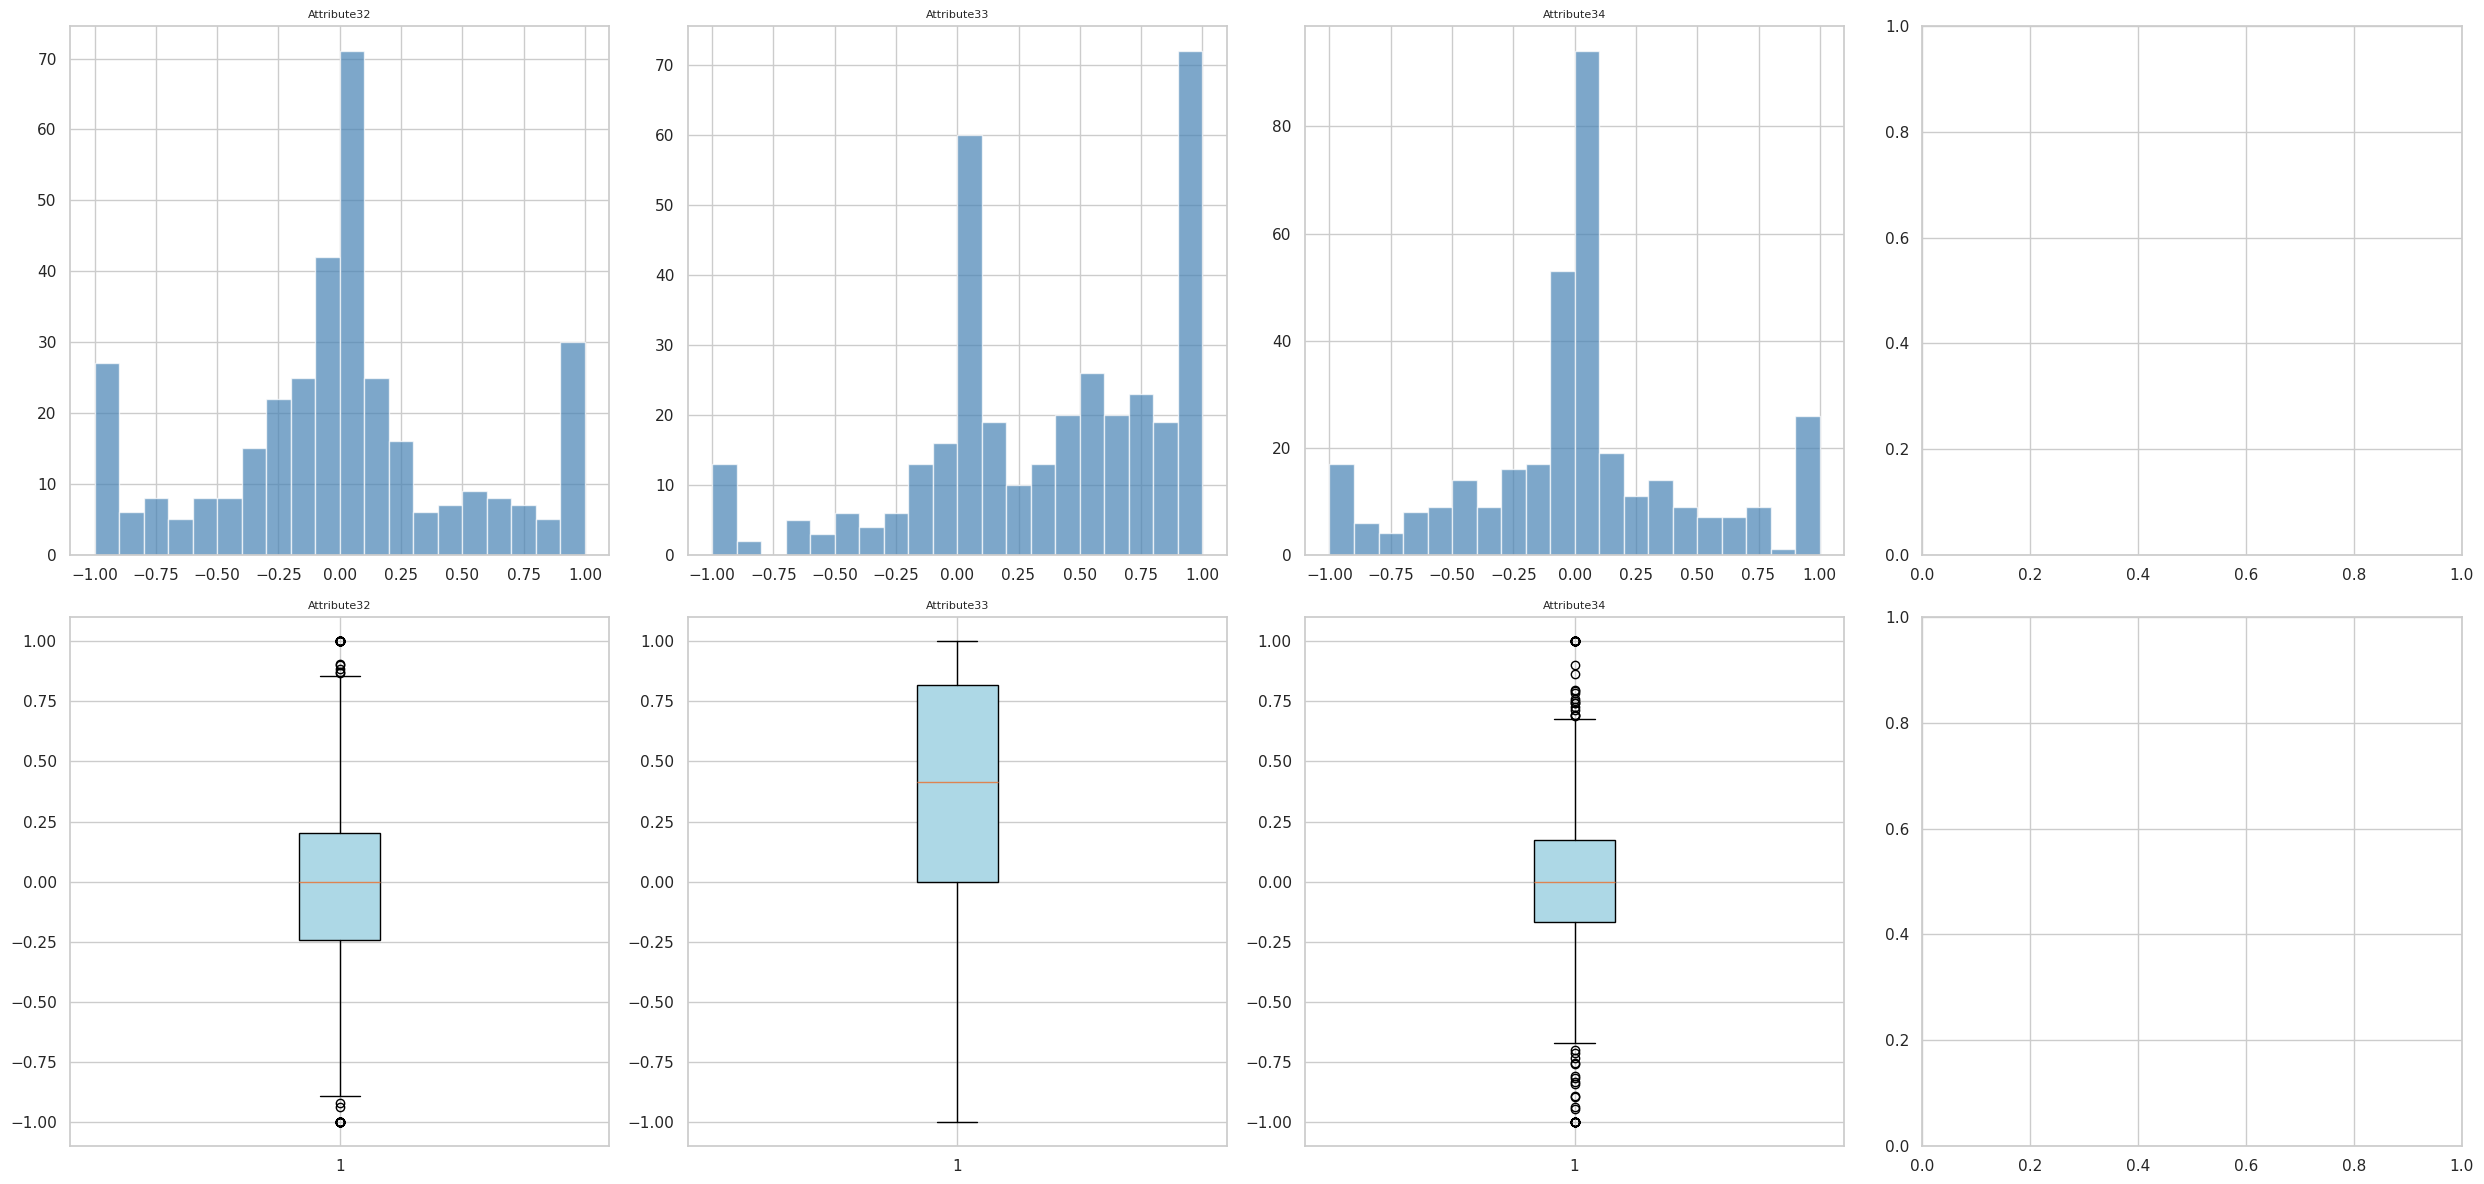

In [17]:
# Features 31-34
plotUnivariate(30,34)

#### Importante / Key

***Observações:*** A análise univariada revelou que diversas features apresentam distribuições assimétricas, com caudas alongadas predominantemente à direita (assimetria positiva). Além disso, os boxplots indicam a presença de outliers em várias variáveis – pontos que se afastam significativamente dos quartis.


***Notes:*** The univariate analysis revealed that several features exhibit skewed distributions, with tails that are predominantly long on the right (positive skewness). In addition, the boxplots indicate the presence of outliers in several variables—points that deviate significantly from the quartiles.

### 1.5 Análise bivariada e multivariada / Bivariate and multivariate analysis

#### Matriz de correlação / Correlation Matrix

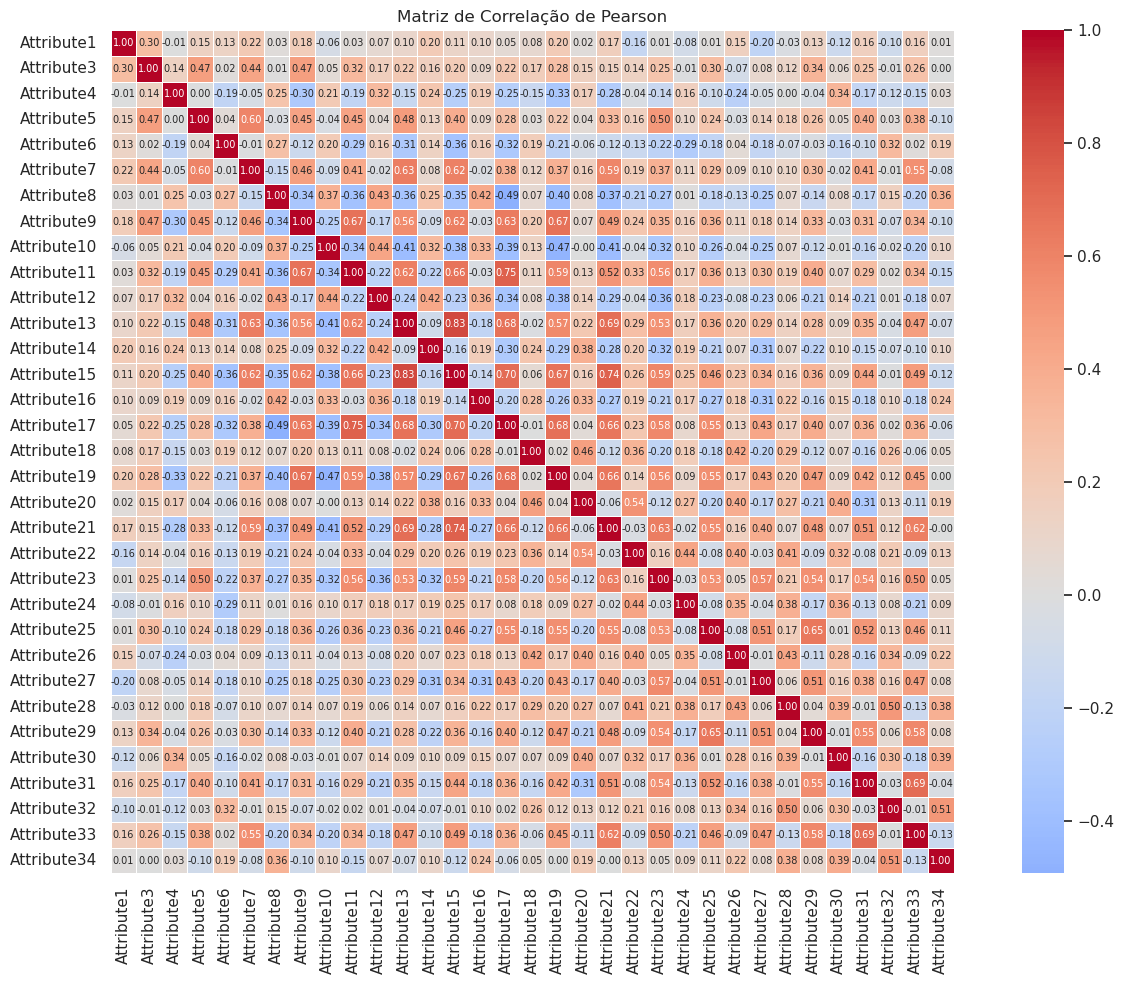

In [18]:
# Matriz de Correlação
plt.figure(figsize=(14, 10))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 7})   # fonte menor para caber
plt.title('Matriz de Correlação de Pearson')
plt.tight_layout()
plt.show()

**Observações:** Não foram observados pares de preditores com correlação > 0,9 (ou sequer moderada alta).

**Notes:** No pairs of predictors with a correlation > 0.9 (or even moderately high) were observed.

#### Correlação entre Preditores e Variável Alvo (PT-BR) / Preditor-Target Correlation 

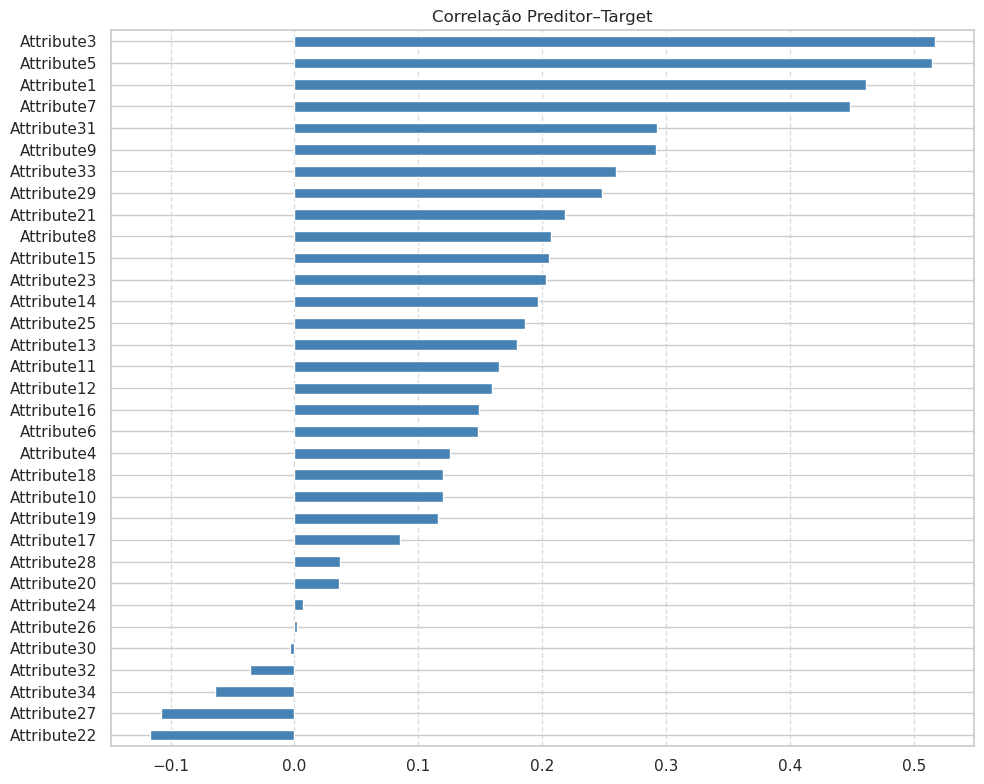

In [19]:
# correlação com o target
corr = X.apply(lambda c: np.corrcoef(c, y)[0, 1])
corr.sort_values().plot(kind='barh', figsize=(10, 8), color='steelblue')
plt.title('Correlação Preditor–Target')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Observações:** Nenhuma feature sozinha tem correlação forte com o target (todas |r| < ~0,5).
Isso sugere que a separação linear simples entre good e bad não é trivial


**Notes:** No single feature has a strong correlation with the target (all |r| < ~0.5).
This suggests that the simple linear separation between good and bad is not trivial

#### Potencial discriminativo / Discriminative potential 

/tmp/ipykernel_18530/1500217931.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='c', y='x', data=temp, ax=axes[i], palette='Set2')
/tmp/ipykernel_18530/1500217931.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='c', y='x', data=temp, ax=axes[i], palette='Set2')
/tmp/ipykernel_18530/1500217931.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='c', y='x', data=temp, ax=axes[i], palette='Set2')
/tmp/ipykernel_18530/1500217931.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed i

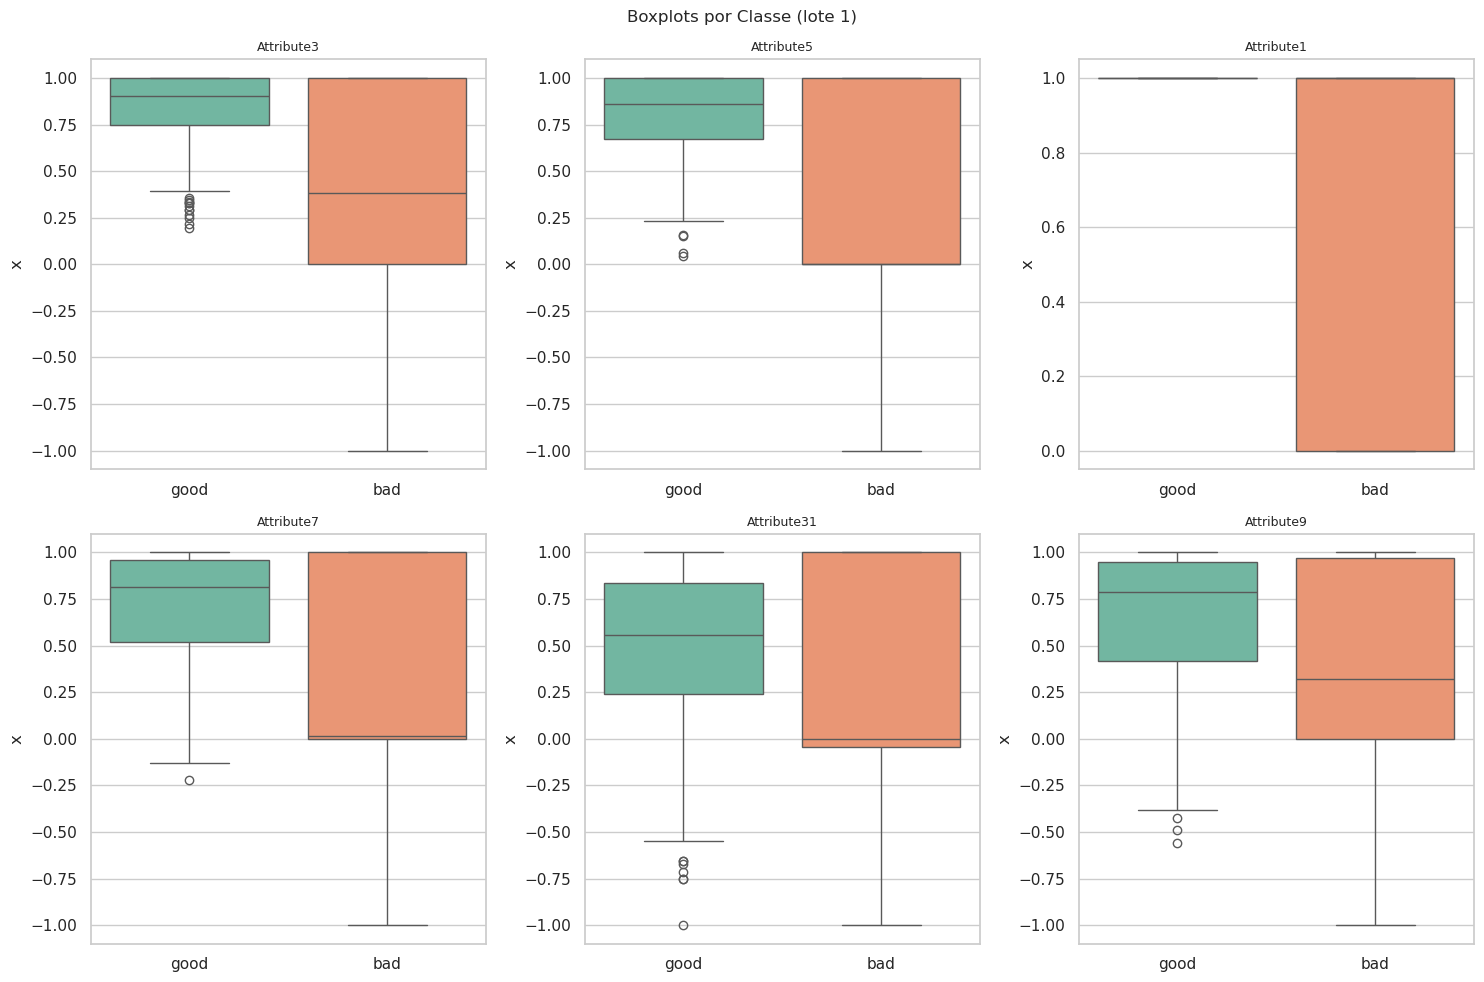

/tmp/ipykernel_18530/1500217931.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='c', y='x', data=temp, ax=axes[i], palette='Set2')
/tmp/ipykernel_18530/1500217931.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='c', y='x', data=temp, ax=axes[i], palette='Set2')
/tmp/ipykernel_18530/1500217931.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='c', y='x', data=temp, ax=axes[i], palette='Set2')
/tmp/ipykernel_18530/1500217931.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed i

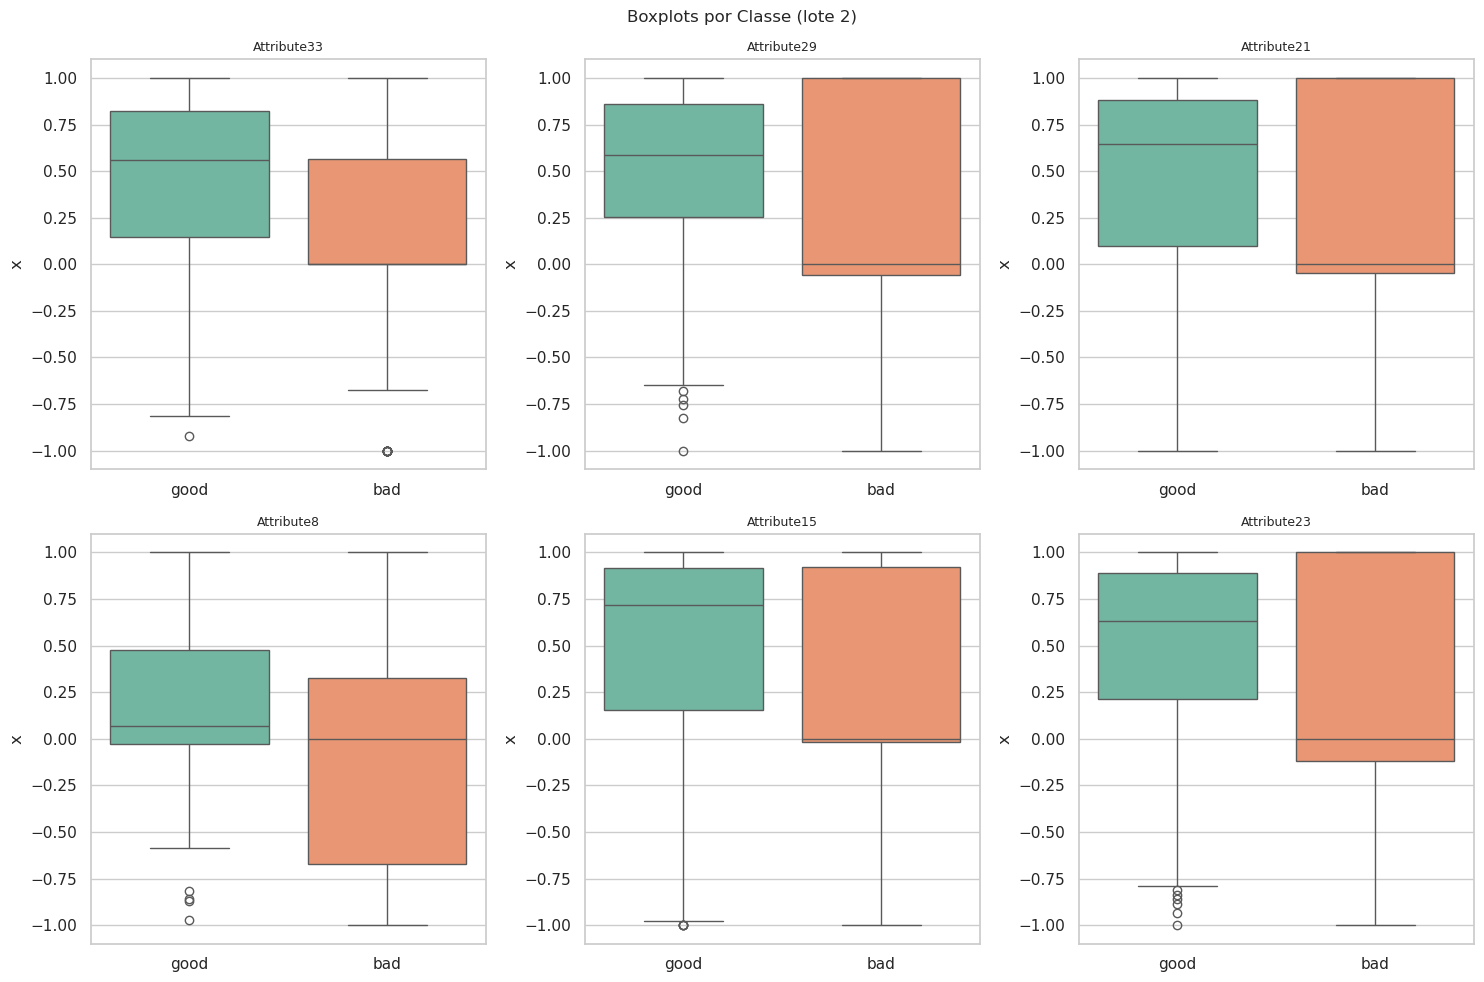

/tmp/ipykernel_18530/1500217931.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='c', y='x', data=temp, ax=axes[i], palette='Set2')
/tmp/ipykernel_18530/1500217931.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='c', y='x', data=temp, ax=axes[i], palette='Set2')
/tmp/ipykernel_18530/1500217931.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='c', y='x', data=temp, ax=axes[i], palette='Set2')
/tmp/ipykernel_18530/1500217931.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed i

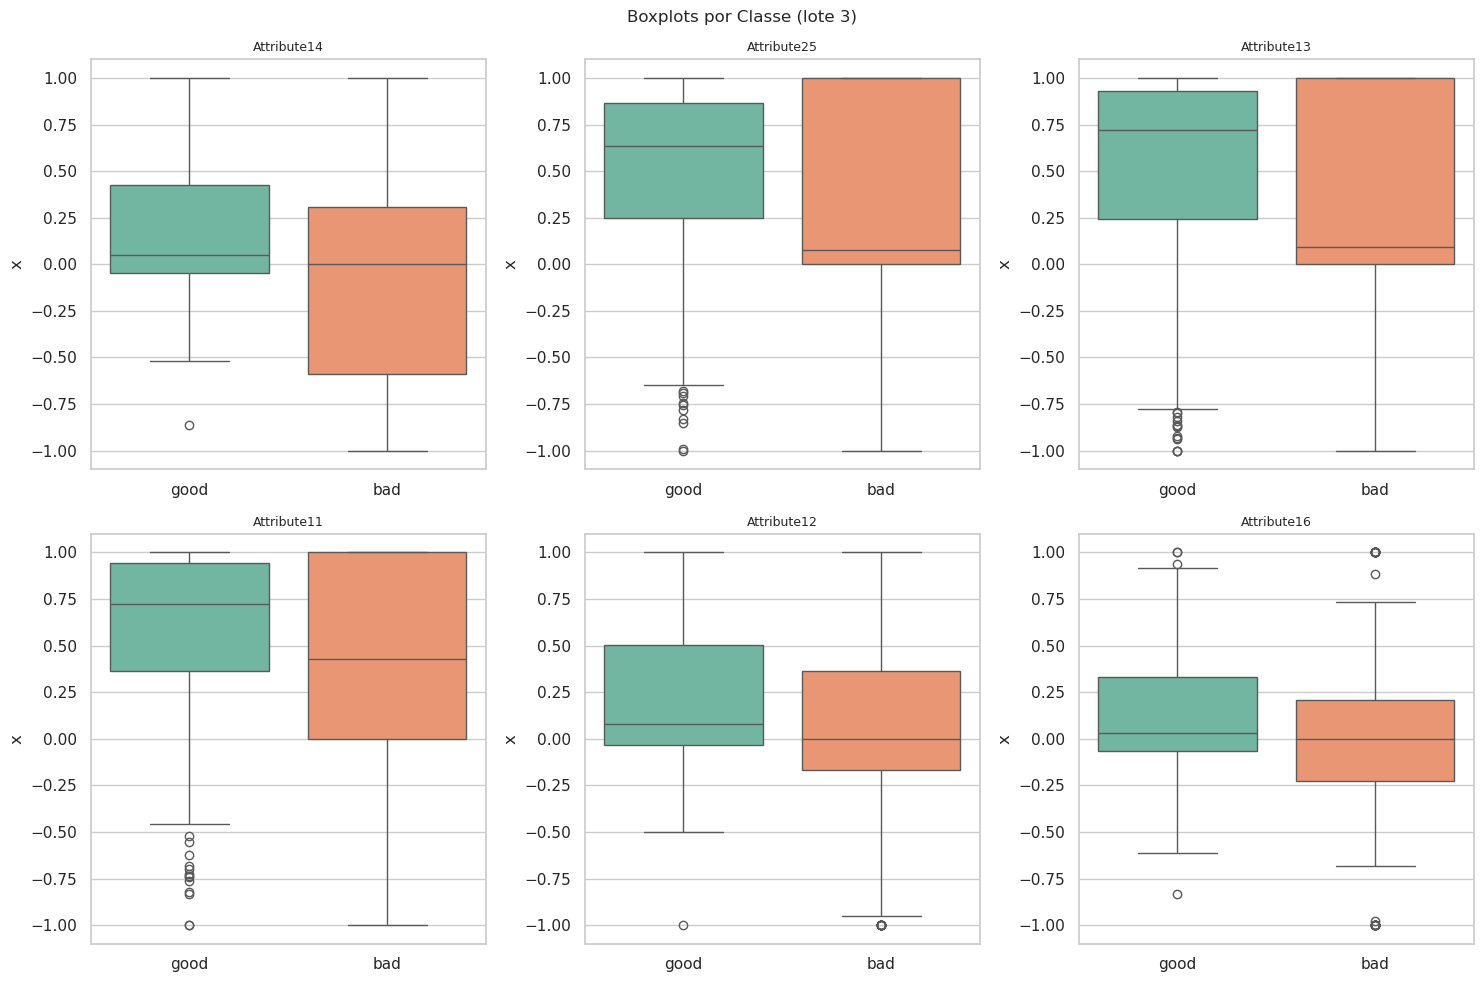

/tmp/ipykernel_18530/1500217931.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='c', y='x', data=temp, ax=axes[i], palette='Set2')
/tmp/ipykernel_18530/1500217931.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='c', y='x', data=temp, ax=axes[i], palette='Set2')
/tmp/ipykernel_18530/1500217931.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='c', y='x', data=temp, ax=axes[i], palette='Set2')
/tmp/ipykernel_18530/1500217931.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed i

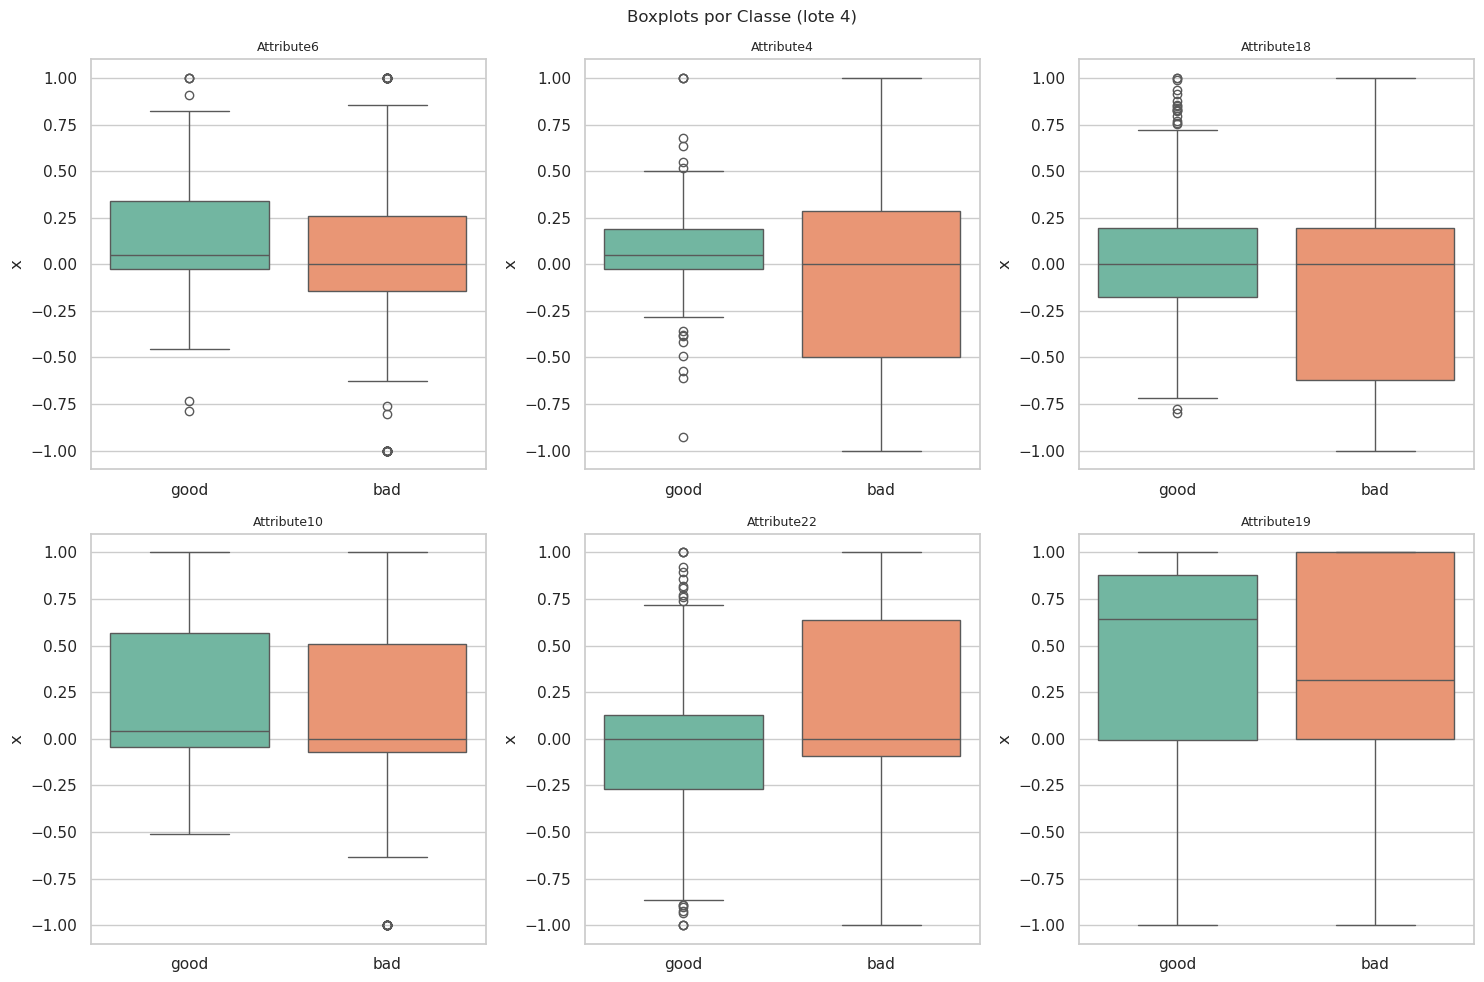

/tmp/ipykernel_18530/1500217931.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='c', y='x', data=temp, ax=axes[i], palette='Set2')
/tmp/ipykernel_18530/1500217931.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='c', y='x', data=temp, ax=axes[i], palette='Set2')
/tmp/ipykernel_18530/1500217931.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='c', y='x', data=temp, ax=axes[i], palette='Set2')
/tmp/ipykernel_18530/1500217931.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed i

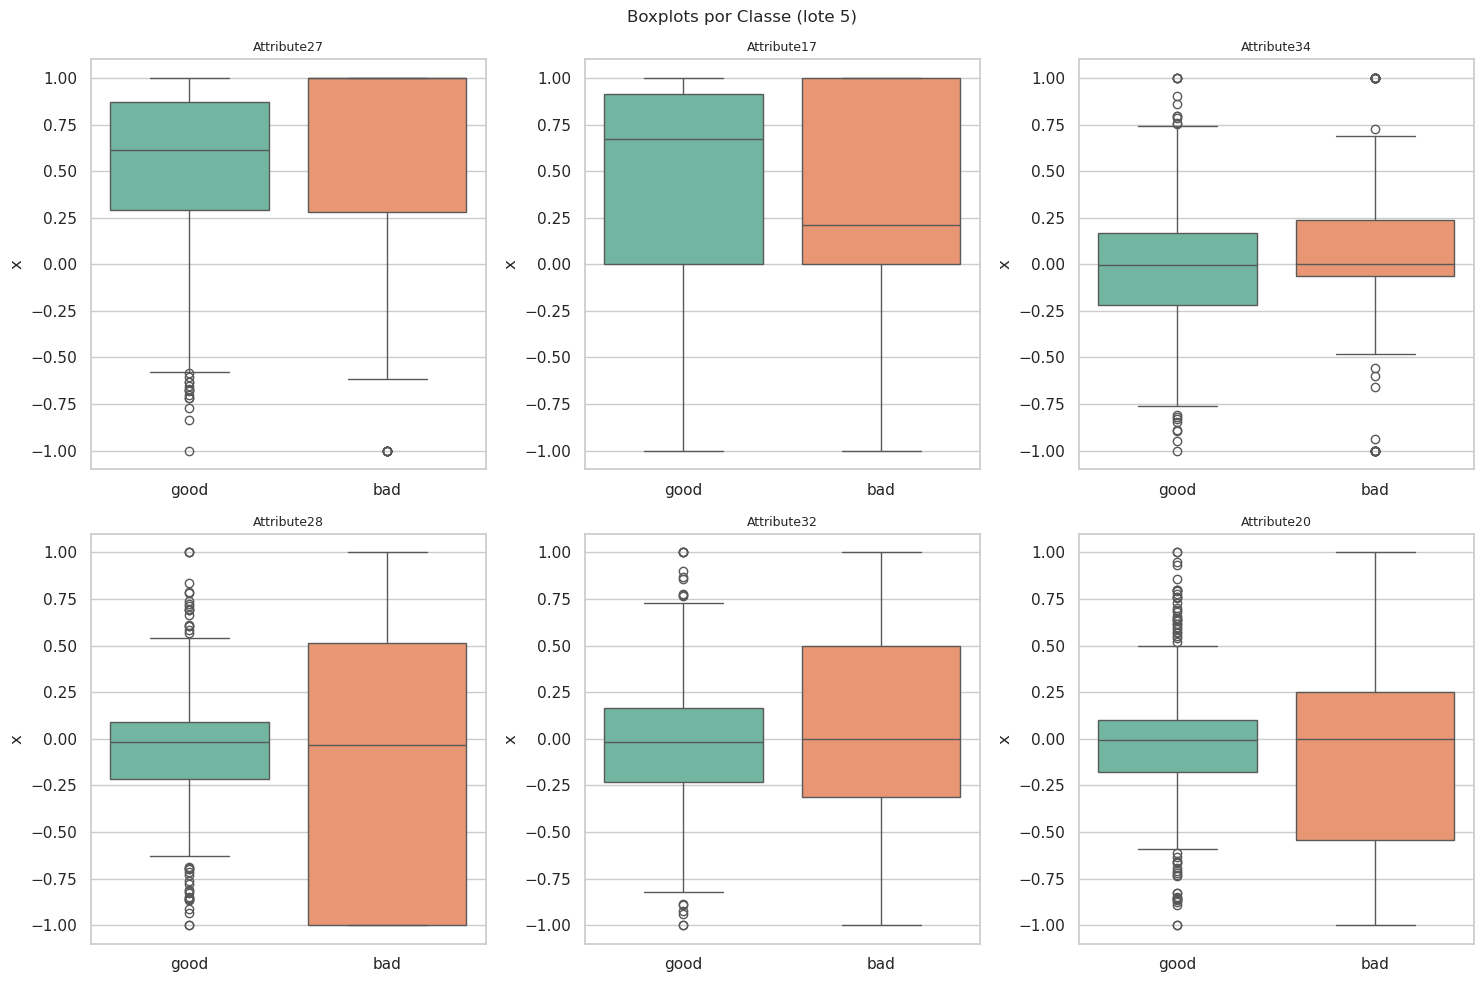

/tmp/ipykernel_18530/1500217931.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='c', y='x', data=temp, ax=axes[i], palette='Set2')
/tmp/ipykernel_18530/1500217931.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='c', y='x', data=temp, ax=axes[i], palette='Set2')
/tmp/ipykernel_18530/1500217931.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='c', y='x', data=temp, ax=axes[i], palette='Set2')


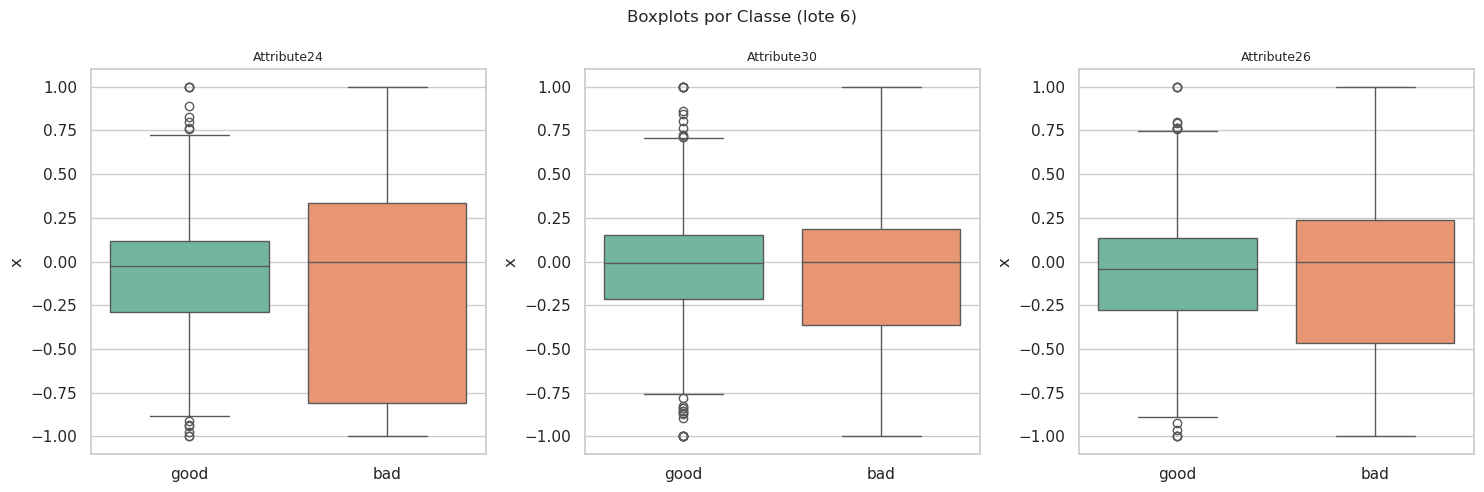

In [20]:
def plot_boxplots_por_classe(X, y, por_fig=6, salvar_prefixo='boxplot_classe'):
    """
    Exibe boxplots de todas as features separadas por classe (good vs bad).
    As features são ordenadas da maior para a menor correlação absoluta com y.
    Gera uma figura nova a cada 'por_fig' features.

    Parâmetros:
    X : DataFrame com as features
    y : array bipolar (+1/-1)
    por_fig : quantos subplots por figura (padrão 6, grade 2x3)
    salvar_prefixo : prefixo dos arquivos PNG salvos
    """

    # Ordena features pela correlação absoluta (maior → menor)
    corr_abs = X.apply(lambda col: np.abs(np.corrcoef(col, y)[0, 1]))
    ordem = corr_abs.sort_values(ascending=False).index.tolist()

    n_features = len(ordem)
    n_figs = int(np.ceil(n_features / por_fig))

    for fig_idx in range(n_figs):
        inicio = fig_idx * por_fig
        fim = min(inicio + por_fig, n_features)
        features_lote = ordem[inicio:fim]
        n_lote = len(features_lote)

        # Cria grade 2x3 (ajusta se o último lote tiver menos de 6)
        n_cols = 3
        n_rows = int(np.ceil(n_lote / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
        axes = np.atleast_1d(axes).flatten()  # garante iterável

        for i, feat in enumerate(features_lote):
            temp = pd.DataFrame({'x': X[feat], 'c': y}).replace({'c': {1: 'good', -1: 'bad'}})
            sns.boxplot(x='c', y='x', data=temp, ax=axes[i], palette='Set2')
            axes[i].set_title(feat, fontsize=9)
            axes[i].set_xlabel('')

        # Remove eixos vazios (se n_lote < por_fig)
        for j in range(n_lote, len(axes)):
            fig.delaxes(axes[j])

        plt.suptitle(f'Boxplots por Classe (lote {fig_idx+1})', fontsize=12)
        plt.tight_layout()
        plt.show()

# Exemplo de uso:
plot_boxplots_por_classe(X, y, por_fig=6, salvar_prefixo='boxplot_classe')

***Observações:*** A maioria das features exibe forte sobreposição entre as caixas de good e bad, indicando que, individualmente, as distribuições das duas classes se confundem bastante. Em contrapartida, as medianas variam de forma visível entre as classes, especialmente nas features de maior correlação absoluta com o target. Ou seja, embora os intervalos interquartis se cruzem, a tendência central difere: a maioria das features tende a deslocar a mediana para cima ou para baixo conforme a classe.

***Notes:*** Most features show significant overlap between the “good” and “bad” boxes, indicating that, individually, the distributions of the two classes are highly confounded. In contrast, the medians vary noticeably between classes, especially for features with the highest absolute correlation with the target. In other words, although the interquartile ranges overlap, the central tendency differs: most features tend to shift the median upward or downward depending on the class.

### 1.6 Etapa 1 – Resumo (PT-BR) / Step 1 – Summary (EN_US)
<details>
  <summary><h4 style="display: inline;">PT-BR</h4></summary>

**1. Dataset após limpeza**
- Amostras: 351 (sem duplicatas detectadas, sem valores ausentes)
- Features originais: 34
- Features removidas: Attribute1 e Attribute2 (constantes, desvio padrão ≈ 0)
- Features ativas: 32 preditores contínuos
- Target: bipolar (+1 = good, −1 = bad), 225 × 126

**2. Escala e normalização**
- As 32 features apresentam escalas muito diferentes (mínimos, máximos e amplitudes variam ordens de grandeza).
- Z-score obrigatório: sem padronização, a regra Delta seria dominada por features de maior magnitude. A normalização equaliza as variâncias e deixa a superfície de erro mais esférica, condição essencial para convergência estável.

**3. Distribuições**
- Muitas features são assimétricas (cauda longa à direita) e contêm outliers visíveis nos boxplots.
- A padronização Z-score reduz o impacto escalar dos outliers, mas eles ainda podem influenciar o gradiente durante o treinamento.
- Consequência: η precisa ser escolhido com cuidado — valores altos podem amplificar oscilações; valores baixos podem retardar a convergência.

**4. Correlações**
- Entre preditores: não foi observada multicolinearidade severa (nenhum par com |r| > 0.9). Os pesos da Adaline tendem a ser estáveis, sem necessidade de regularização extra.
- Preditor–target: as correlações lineares individuais são fracas (todas |r| < ~0.5). Nenhuma feature sozinha separa bem as classes.
- As correlações são dominadas por um pequeno grupo de atributos (ex.: Attribute3, Attribute5, Attribute1 — já removido, etc.), que concentram a maior parte da informação linear.

**5. Boxplots por classe**
- Sobreposição forte na maioria das features: as caixas de good e bad se cruzam bastante.
- Medianas variam entre as classes, mesmo quando há sobreposição.
- Top 6 features (maior |r| com target): a sobreposição diminui significativamente. Essas variáveis concentram o poder discriminativo linear.

**6. Implicações para a modelagem (Adaline)**
- Problema não é linearmente trivial — a acurácia provavelmente será moderada.
- A combinação linear dos 32 preditores pode capturar padrões que isoladamente são fracos.
- Sem multicolinearidade → pesos devem ser interpretáveis.
- Outliers e assimetria → justificam o estudo de múltiplos valores de η para encontrar convergência suave.
- Features constantes removidas → dimensionalidade reduzida sem perda de informação.
- A escolha do η ideal será crítica: curvas de perda devem ser inspecionadas para estabilidade e menor MSE final.

</details>

<details>
  <summary><h4 style="display: inline;">EN-US</h4></summary>

**1. Dataset after cleaning**
- Samples: 351 (no duplicates detected, no missing values)
- Original features: 34
- Removed features: Attribute1 and Attribute2 (constant, standard deviation ≈ 0)
- Active features: 32 continuous predictors
- Target: bipolar (+1 = good, −1 = bad), 225 vs 126

**2. Scale and normalization**
- The 32 features have very different scales (min, max, and ranges vary by orders of magnitude).
- Z-score is mandatory: without standardization, the Delta rule would be dominated by larger‑magnitude features. Normalization equalizes variances and makes the error surface more spherical – essential for stable convergence.

**3. Distributions**
- Many features are asymmetric (long right tail) and contain visible outliers in boxplots.
- Z-score standardization reduces the scale impact of outliers, but they can still influence the gradient during training.
- Consequence: η must be chosen carefully – high values may amplify oscillations; low values may slow down convergence.

**4. Correlations**
- Between predictors: no severe multicollinearity observed (no pair with |r| > 0.9). Adaline weights tend to be stable, no need for extra regularization.
- Predictor–target: individual linear correlations are weak (all |r| < ~0.5). No single feature separates the classes well.
- Correlations are dominated by a small group of attributes (e.g., Attribute3, Attribute5, Attribute1 – already removed, etc.), which concentrate most of the linear information.

**5. Boxplots by class**
- Strong overlap in most features: the boxes of good and bad overlap considerably.
- Medians vary between classes, even when overlap exists.
- Top 6 features (highest |r| with the target): overlap decreases significantly. These variables concentrate the linear discriminative power.

**6. Implications for modeling (Adaline)**
- The problem is not linearly trivial – accuracy will likely be moderate.
- The linear combination of the 32 predictors may capture patterns that are individually weak.
- No multicollinearity → weights should be interpretable.
- Outliers and asymmetry → justify testing multiple η values to find smooth convergence.
- Constant features removed → reduced dimensionality without loss of information.
- The choice of η will be critical: loss curves must be inspected for stability and lowest final MSE.

</details>

## Etapa 2 – Validação das Premissas do Modelo (PT-BR) / Step 2 – Validate Modeling Assumptions (EN-US)

<details>
  <summary><h3 style="display: inline;">Detalhes (PT-BR)</h3></summary>

- Verificar se a relação preditor‑target é aproximadamente linear (condição para a Adaline).
- Analisar a correlação entre preditores; alta correlação não inviabiliza, mas pode exigir regularização.
- Confirmar que o target está codificado corretamente como bipolar (+1/–1).
- Avaliar balanceamento das classes (225 vs 126) e considerar seu impacto no viés do modelo.
- Checar se os dados normalizados atendem à suposição de distribuição aproximadamente simétrica (desejável para convergência rápida da regra Delta).
</details>

<details>
  <summary><h3 style="display: inline;">Details (EN-US)</h3></summary>

- Check that the predictor–target relationship is roughly linear (Adaline requirement).
- Analyze predictor–predictor correlation; high correlation does not break the model but may suggest redundancy.
- Confirm target is properly encoded as bipolar (+1/–1).
- Assess class balance (225 vs 126) and its influence on bias.
- Verify that normalized data show approximately symmetric distributions (desirable for fast Delta rule convergence).
</details>

<br>

O código abaixo é uma tentativa de visualizar as classes e ilustrar um hierplano de separação, o método PCA (Análise de Componentes Principais) para o problema atual não demostrou uma boa representação do que se buscava, optando por uma estratégia alternativa.


Ridge (CV) R2: 0.151 ± 0.211
Ridge (CV) MSE: 0.671 ± 0.330


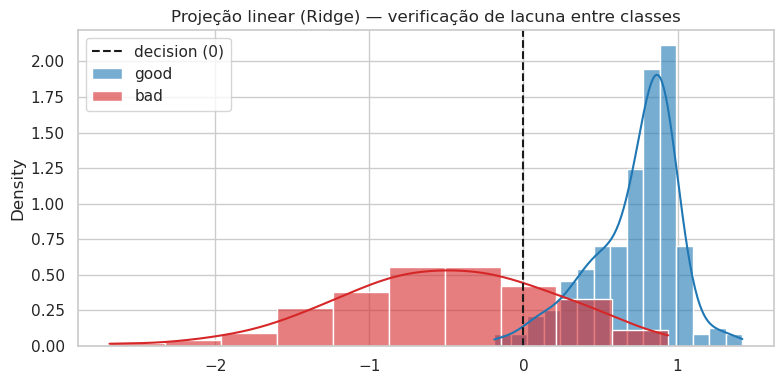

In [21]:
# X (DataFrame) e y (array +1/-1) já Existem
X_arr = X.values if hasattr(X, 'values') else np.asarray(X)
y_arr = np.asarray(y)

# padronizar (já usado em células anteriores)
scaler_full = StandardScaler().fit(X_arr)
X_s = scaler_full.transform(X_arr)

# 1) Correlações simples (Pearson) entre cada preditor e o target
corr = X.apply(lambda c: np.corrcoef(c, y)[0,1]).sort_values(ascending=False)

# 2) Regressão linear (Ridge) para prever y (contínuo ±1) — CV para avaliar força linear global
ridge = Ridge(alpha=1.0)

r2_scores = cross_val_score(ridge, X_s, y_arr, cv=5, scoring='r2', n_jobs=-1)
mse_scores = -cross_val_score(ridge, X_s, y_arr, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

print('\nRidge (CV) R2: %.3f ± %.3f' % (r2_scores.mean(), r2_scores.std()))
print('Ridge (CV) MSE: %.3f ± %.3f' % (mse_scores.mean(), mse_scores.std()))

# Fit para inspecionar coeficientes
ridge.fit(X_s, y_arr)
coef = pd.Series(ridge.coef_, index=X.columns)

# 3) Projeção na direção do modelo linear (w^T x) — mostra se existe lacuna entre classes
proj = X_s.dot(ridge.coef_) + ridge.intercept_

plt.figure(figsize=(8,4))

sns.histplot(proj[y_arr==1], color='tab:blue', label='good', stat='density', alpha=0.6, kde=True)
sns.histplot(proj[y_arr==-1], color='tab:red',  label='bad',  stat='density', alpha=0.6, kde=True)

plt.axvline(0, color='k', linestyle='--', label='decision (0)')
plt.title('Projeção linear (Ridge) — verificação de lacuna entre classes')
plt.legend(); plt.tight_layout(); plt.show()

# Interpretação rápida impressa
frac_overlap = np.mean((proj > proj.mean() - proj.std()) & (proj < proj.mean() + proj.std()))

**Observação:** R2 próximo de 0 e histogramas muito sobrepostos indicam relação linear fraca.
Se R2 for significativamente negativo ou próximo de 0 o problema não é bem descrito por uma aproximação de hiperplano linear simples.

## Etapa 3 – Seleção de Atributos (PT-BR) / Step 3 – Feature Selection (EN-US)

<details>
  <summary><h3 style="display: inline;">Detalhes (PT-BR)</h3></summary>

- Iniciar com todas as 34 features; a remoção só é necessária se houver atributos constantes ou quase constantes identificados na Etapa 1.
- Se desejado, ranquear features pela correlação absoluta com o target.
- Considerar que a Adaline com muitos atributos correlacionados ainda converge, mas pesos podem ser menos interpretáveis.
- Manter um registo das features usadas para a etapa de análise de coeficientes.
</details>

<details>
  <summary><h3 style="display: inline;">Details (EN-US)</h3></summary>

- Start with all 34 features; removal only if constant/near‑constant attributes were found in Step 1.
- If desired, rank features by absolute correlation with the target.
- Note that Adaline with many correlated features will still converge, though weight interpretation may suffer.
- Keep a record of the final feature set for later coefficient analysis.
</details>

<br>

In [22]:
# Cópia limpa dos dados
data = X.copy()
y_target = y.copy()

## Etapa 4 – Divisão dos Dados (PT-BR) / Step 4 – Data Split (EN-US)

<details>
  <summary><h3 style="display: inline;">Detalhes (PT-BR)</h3></summary>

- Separar 80% para treino e 20% para teste com `train_test_split` estratificado (`stratify=y`).
- Usar semente aleatória fixa (`random_state=42`) para reprodutibilidade.
- Verificar se a proporção das classes se mantém em ambos os subconjuntos.
</details>

<details>
  <summary><h3 style="display: inline;">Details (EN-US)</h3></summary>

- Split data into 80% training and 20% testing with stratification (`stratify=y`).
- Use a fixed random seed (`random_state=42`) for reproducibility.
- Confirm that the class distribution is preserved in both subsets.
</details>

<br>


In [23]:
# Divisao treino / teste com estratificação para teste
X_train, X_test, y_train, y_test = train_test_split(
    data, y_target, test_size=0.2, random_state=42, stratify=y_target
)

In [24]:
# Divisao treino / teste sem estratificação para teste
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    data, y_target, test_size=0.2,
)

In [25]:
# Comparar contagens de classes COM vs SEM stratify
print("=" * 80)
print("DATASET ORIGINAL:")
print("  Total amostras:", len(y_target))
print("  Class +1 (good):", np.sum(y_target == 1), f"({100*np.sum(y_target == 1)/len(y_target):.1f}%)")
print("  Class -1 (bad):", np.sum(y_target == -1), f"({100*np.sum(y_target == -1)/len(y_target):.1f}%)")

print("\n" + "=" * 80)
print("COM STRATIFY (estratificado):")
print(f"  TREINO ({len(y_train)} amostras):")
print(f"    +1 (good): {np.sum(y_train == 1)} ({100*np.sum(y_train == 1)/len(y_train):.1f}%)")
print(f"    -1 (bad):  {np.sum(y_train == -1)} ({100*np.sum(y_train == -1)/len(y_train):.1f}%)")
print(f"  TESTE ({len(y_test)} amostras):")
print(f"    +1 (good): {np.sum(y_test == 1)} ({100*np.sum(y_test == 1)/len(y_test):.1f}%)")
print(f"    -1 (bad):  {np.sum(y_test == -1)} ({100*np.sum(y_test == -1)/len(y_test):.1f}%)")

print("\n" + "=" * 80)
print("SEM STRATIFY (aleatório puro):")
print(f"  TREINO ({len(y_train2)} amostras):")
print(f"    +1 (good): {np.sum(y_train2 == 1)} ({100*np.sum(y_train2 == 1)/len(y_train2):.1f}%)")
print(f"    -1 (bad):  {np.sum(y_train2 == -1)} ({100*np.sum(y_train2 == -1)/len(y_train2):.1f}%)")
print(f"  TESTE ({len(y_test2)} amostras):")
print(f"    +1 (good): {np.sum(y_test2 == 1)} ({100*np.sum(y_test2 == 1)/len(y_test2):.1f}%)")
print(f"    -1 (bad):  {np.sum(y_test2 == -1)} ({100*np.sum(y_test2 == -1)/len(y_test2):.1f}%)")


DATASET ORIGINAL:
  Total amostras: 350
  Class +1 (good): 225 (64.3%)
  Class -1 (bad): 125 (35.7%)

COM STRATIFY (estratificado):
  TREINO (280 amostras):
    +1 (good): 180 (64.3%)
    -1 (bad):  100 (35.7%)
  TESTE (70 amostras):
    +1 (good): 45 (64.3%)
    -1 (bad):  25 (35.7%)

SEM STRATIFY (aleatório puro):
  TREINO (280 amostras):
    +1 (good): 175 (62.5%)
    -1 (bad):  105 (37.5%)
  TESTE (70 amostras):
    +1 (good): 50 (71.4%)
    -1 (bad):  20 (28.6%)


A própria biblioteca já possui mecanismos e valores padrões que evitam o desbalanceamento da classe:
- Desbalanceamento moderado: 64-36 é bem equilibrado. Desbalanceamento crítico começa em 80-20 ou piores (90-10, 95-5).
- Aleatoriedade baixa: Sem stratify, a flutuação é insignificante. Com 350 amostras, o efeito aleatório é amortecido.

Mecanismos do sklearn:
- SGDClassifier e LogisticRegression já possuem class_weight='balanced' opcional
- cross_val_score com StratifiedKFold é mais robusto para CV

## Etapa 5 – Normalização/Padronização (PT-BR) / Step 5 – Normalization/Scaling (EN-US)

<details>
  <summary><h3 style="display: inline;">Detalhes (PT-BR)</h3></summary>

- Aplicar padronização Z‑score (`StandardScaler`) após a divisão treino‑teste.
- Ajustar o scaler somente no conjunto de treino; transformar treino e teste com os mesmos parâmetros.
- Justificativa algébrica: a regra Delta atualiza pesos com `w = w + η (y - ŷ) x`. Features em escalas diferentes tornam a superfície de erro alongada, exigindo η muito pequeno e causando convergência lenta. A padronização equaliza as variâncias, permitindo um η estável.
</details>

<details>
  <summary><h3 style="display: inline;">Details (EN-US)</h3></summary>

- Apply Z‑score normalization (`StandardScaler`) after the train‑test split.
- Fit the scaler only on the training set; transform both sets with the fitted parameters.
- Algebraic justification: the Delta rule updates weights via `w = w + η (y - ŷ) x`. Different scales stretch the error surface, requiring a very small η and causing slow convergence. Standardization equalizes variances, enabling a stable learning rate.
</details>

<br>


In [26]:
# Normalização padrão
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## Etapa 6 – Ajuste do Modelo (Adaline) (PT-BR) / Step 6 – Model Fitting (Adaline) (EN-US)

<details>
  <summary><h3 style="display: inline;">Detalhes (PT-BR)</h3></summary>

- Implementar a rede Adaline usando `SGDClassifier` com `loss='squared_error'` e `learning_rate='constant'`.
- Testar múltiplas taxas de aprendizagem: 10⁻⁴, 10⁻³, 10⁻², 5×10⁻², 10⁻¹, com `max_iter=200` e registrando a função de perda (MSE) a cada época.
- Plotar a curva de convergência (MSE vs épocas) para cada η.
- Selecionar o η que proporcionar a convergência mais suave e o menor erro final (considerando uma combinação de erro final e estabilidade).
</details>

<details>
  <summary><h3 style="display: inline;">Details (EN-US)</h3></summary>

- Implement Adaline using `SGDClassifier` with `loss='squared_error'` and constant learning rate.
- Test multiple learning rates: 1e‑4, 1e‑3, 1e‑2, 5e‑2, 1e‑1, with `max_iter=200` and record the MSE loss at each epoch.
- Plot convergence curves (MSE vs epochs) for each η.
- Choose the η that yields the smoothest convergence and smallest final loss (balancing final error and stability).
</details>

<br>

In [27]:
# hiperparâmetros solicitados
etas = [1e-4, 1e-3, 1e-2, 5e-2, 1e-1]
epochs = 200

In [28]:
# dicionário para salvar resutlados
cv_results = {}

for eta in etas:
    clf = SGDClassifier(
        loss='squared_error',  # Adaline
        eta0=eta,  # taxa de apredizados diferentes
        max_iter=200,  # iterações
        shuffle=True,  # embaralhar
        #random_state=42,
        n_jobs=-1  # todos os cpus se setado com -1
    )
    
    # 5-fold CV - classificadores diferentes para cross validation
    scores = cross_val_score(
        clf, X_train_scaled, y_train, 
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='accuracy'
    )
    
    cv_results[eta] = {
        'mean': scores.mean(),
        'std': scores.std()
    }
    
    print(f"n = {eta:.1e}: Acurácia = {scores.mean():.4f} ± {scores.std():.4f}")


n = 1.0e-04: Acurácia = 0.5643 ± 0.1310
n = 1.0e-03: Acurácia = 0.4643 ± 0.1253
n = 1.0e-02: Acurácia = 0.5857 ± 0.1025
n = 5.0e-02: Acurácia = 0.4357 ± 0.1161
n = 1.0e-01: Acurácia = 0.5750 ± 0.1148


In [29]:
best_eta = max(cv_results, key=lambda x: cv_results[x]['mean'])

print(f"\n Melhor n: {best_eta}")


 Melhor n: 0.01


In [30]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) #  cria um divisor de validação cruzada estratificada com 5 fold

# detectar formato dos rótulos
labels_are_01 = set(np.unique(y_train)).issubset({0,1}) # converte os rótulos para um map com -1 e 1 usnado o truque y = y * 2 - 1

# dicionários para salvar as etapas para gráfico de erro
results_train = {}
results_val = {}

# estratégia clássica para ter os dados para o gráfico de erro(MSE) por época
for eta in etas:
    fold_train_losses = []
    fold_val_losses = []
    
    for train_idx, val_idx in skf.split(X_train_scaled, y_train):
        Xtr = X_train_scaled[train_idx].astype(float)
        Xval = X_train_scaled[val_idx].astype(float)
        ytr = y_train[train_idx].astype(float)
        yval = y_train[val_idx].astype(float)

        n = Xtr.shape[0]
        w = np.zeros(Xtr.shape[1], dtype=float)
        b = 0.0

        train_losses = np.zeros(epochs, dtype=float)
        val_losses = np.zeros(epochs, dtype=float)
        
        for ep in range(epochs):
            # calcular perda no treino
            ytr_pred = Xtr @ w + b
            train_losses[ep] = np.mean((ytr - ytr_pred) ** 2)

            # calcular perda na validação
            yval_pred = Xval @ w + b
            val_losses[ep] = np.mean((yval - yval_pred) ** 2)

            # atualização batch (Delta rule) usando conjunto de treino
            err = ytr - ytr_pred
            w = w + eta * (Xtr.T @ err) / n
            b = b + eta * np.mean(err)

        fold_train_losses.append(train_losses)
        fold_val_losses.append(val_losses)

    # média das losses entre folds (MSE médio por época)
    results_train[eta] = np.mean(np.vstack(fold_train_losses), axis=0)
    results_val[eta] = np.mean(np.vstack(fold_val_losses), axis=0)

**Nota:** best_eta já foi definido pela acurácia CV na célula anterior

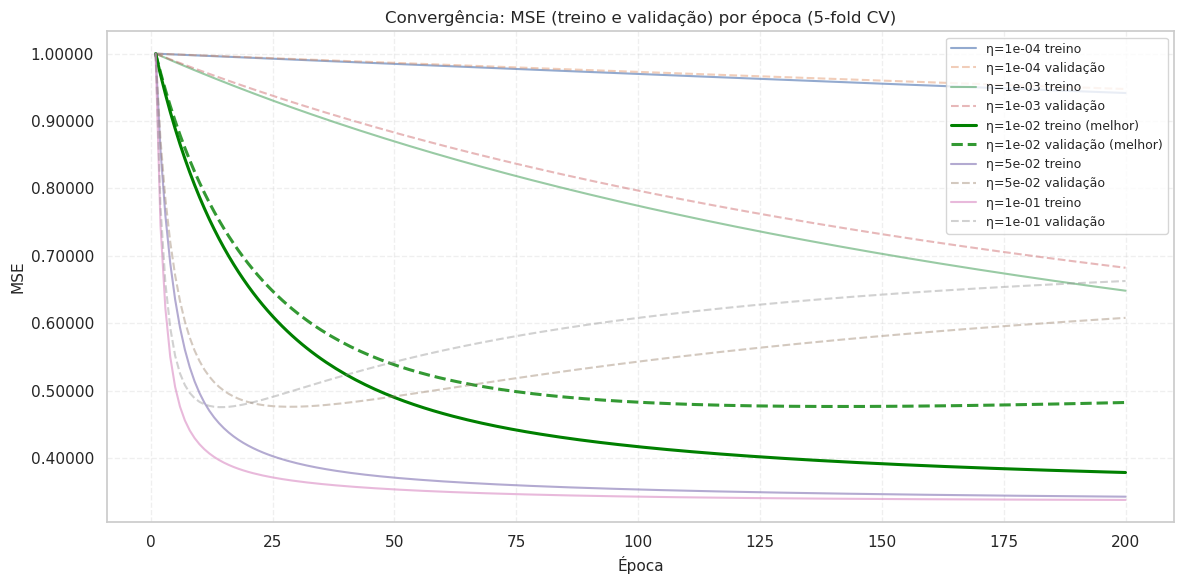

In [31]:
# Convergência: treino e validação por época
fig, ax = plt.subplots(figsize=(12,6))

for eta in etas:
    if eta == best_eta:
        ax.plot(range(1, epochs+1), results_train[eta], label=f'η={eta:.0e} treino (melhor)', 
                color='green', linewidth=2.2, linestyle='-')
        ax.plot(range(1, epochs+1), results_val[eta], label=f'η={eta:.0e} validação (melhor)', 
                color='green', linewidth=2.2, linestyle='--', alpha=0.8)
    else:
        ax.plot(range(1, epochs+1), results_train[eta], label=f'η={eta:.0e} treino', 
                alpha=0.6, linestyle='-')
        ax.plot(range(1, epochs+1), results_val[eta], label=f'η={eta:.0e} validação', 
                alpha=0.4, linestyle='--')

ax.set_xlabel('Época', fontsize=11)
ax.set_ylabel('MSE', fontsize=11)
ax.set_title('Convergência: MSE (treino e validação) por época (5-fold CV)', fontsize=12)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.5f'))
ax.legend(loc='best', fontsize=9)
ax.grid(True, ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Etapa 7 – Avaliação (PT-BR) / Step 7 – Assessment (EN-US)

<details>
  <summary><h3 style="display: inline;">Detalhes (PT-BR)</h3></summary>

- Treinar o modelo final com o melhor η e classificar o conjunto de teste.
- Calcular e apresentar a matriz de confusão.
- Calcular acurácia, precisão, recall e F1‑score (considerando `good` como classe positiva).
- Discutir qual tipo de erro (falso positivo ou falso negativo) é mais crítico no contexto do monitoramento ionosférico.
</details>

<details>
  <summary><h3 style="display: inline;">Details (EN-US)</h3></summary>

- Train the final model with the best η and predict on the test set.
- Compute and display the confusion matrix.
- Compute accuracy, precision, recall, and F1‑score (with `good` as the positive class).
- Discuss which type of error (false positive or false negative) is more critical for ionospheric monitoring.
</details>

<br>

In [37]:
adaline_sklearn = SGDClassifier(
    loss='squared_error',
    eta0=best_eta,
    learning_rate='constant',
    max_iter=200,
    shuffle=True,
    random_state=42 
)

adaline_sklearn.fit(X_train_scaled, y_train)  # ✓ Use dados escalados
y_pred_sklearn = adaline_sklearn.predict(X_test_scaled)


MATRIZ DE CONFUSÃO (good=1, bad=-1):
                  Predito=Good  Predito=Bad
Real=Good (TP/FN):     43                2
Real=Bad  (FP/TN):      6               19


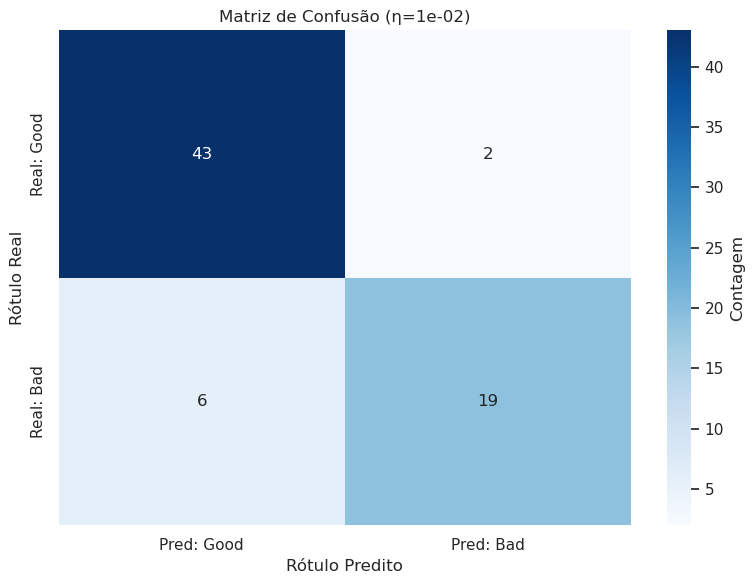

In [38]:
# Calcular matriz de confusão
cm = confusion_matrix(y_test, y_pred_sklearn, labels=[1, -1])  # ordem: good

# Print para visivel para entendimento
print("\n" + "="*60)
print("MATRIZ DE CONFUSÃO (good=1, bad=-1):")
print("="*60)
print(f"                  Predito=Good  Predito=Bad")
print(f"Real=Good (TP/FN):    {cm[0,0]:3d}              {cm[0,1]:3d}")
print(f"Real=Bad  (FP/TN):    {cm[1,0]:3d}              {cm[1,1]:3d}")

# Plotar matriz de confusão
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pred: Good', 'Pred: Bad'],
            yticklabels=['Real: Good', 'Real: Bad'],
            cbar_kws={'label': 'Contagem'})
plt.title(f'Matriz de Confusão (η={best_eta:.0e})')
plt.ylabel('Rótulo Real')
plt.xlabel('Rótulo Predito')
plt.tight_layout()
plt.show()

In [39]:
# Métricas
print('Acurácia :', accuracy_score(y_test, y_pred_sklearn))
print('Precisão  :', precision_score(y_test, y_pred_sklearn, pos_label=1))
print('Recall    :', recall_score(y_test, y_pred_sklearn, pos_label=1))
print('F1-Score  :', f1_score(y_test, y_pred_sklearn, pos_label=1))

Acurácia : 0.8857142857142857
Precisão  : 0.8775510204081632
Recall    : 0.9555555555555556
F1-Score  : 0.9148936170212766


In [40]:
# Calculos de taxa de erros para melhor entendimento
tn, fp, fn, tp = cm[1,1], cm[1,0], cm[0,1], cm[0,0]
total = tp + tn + fp + fn
false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0

# Verificando se os cálculos estão corretos
print("\n" + "="*60)
print("VERIFICAÇÃO DAS MÉTRICAS:")
print("="*60)
print(f"TP (Real +1, Predito +1): {tp}")
print(f"FN (Real +1, Predito -1): {fn}")
print(f"FP (Real -1, Predito +1): {fp}")
print(f"TN (Real -1, Predito -1): {tn}")
print(f"Total: {total}")

print(f"\nRecall (Sensibilidade) = TP/(TP+FN) = {tp}/({tp}+{fn}) = {tp/(tp+fn) if (tp+fn)>0 else 0:.4f}")
print(f"Specificity (TN Rate)  = TN/(FP+TN) = {tn}/({fp}+{tn}) = {tn/(fp+tn) if (fp+tn)>0 else 0:.4f}")
print(f"\nFalse Positive Rate (1-Specificity) = FP/(FP+TN) = {fp}/({fp}+{tn}) = {false_positive_rate:.4f}")
print(f"False Negative Rate (1-Sensitivity) = FN/(FN+TP) = {fn}/({fn}+{tp}) = {false_negative_rate:.4f}")


VERIFICAÇÃO DAS MÉTRICAS:
TP (Real +1, Predito +1): 43
FN (Real +1, Predito -1): 2
FP (Real -1, Predito +1): 6
TN (Real -1, Predito -1): 19
Total: 70

Recall (Sensibilidade) = TP/(TP+FN) = 43/(43+2) = 0.9556
Specificity (TN Rate)  = TN/(FP+TN) = 19/(6+19) = 0.7600

False Positive Rate (1-Specificity) = FP/(FP+TN) = 6/(6+19) = 0.2400
False Negative Rate (1-Sensitivity) = FN/(FN+TP) = 2/(2+43) = 0.0444


### **Erro crítico**
- Se **Classe "good"** (+1): Estrutura ionosférica **detectada** e o sinal está ok com comunicação confiável
- Se **Classe "bad"** (-1): **Ausência** de estrutura ionosférica, possível falha de transmissão, interferência, perda de sinal

Analisando os dois cenários:
- **Falso Positivo (FP):** O sistema diz "tudo bem, sinal OK" quando na verdade há **falha de transmissão**. Acredita-se que o sinal é confiável quando não é, podendo ocorrer perdas na telecomunicação em que sistemas que podem ficar "cegos" sem comunicação.

- **Falso Negativo (FN):** Classificou "bom" como "mal". O sistema relata que existe uma falha, quando na verdade não há, não tendo impacto significativo nos sistemas de comunicação, apenas redundância e desperdício de tempo para checagem e controle do sistema.

Diante disso, o cenário de **Falso Positivo** se mostra mais crítico para o modelo, podendo levar a cenários graves como veículos saindo de rota devido a falha de sistemas como GPS.

### **Conclusão**
Conforme cenário apresentado anteriormente, o modelo Adaline desenvolvido pode ser usado para lidar com o problema proposto, pois apresenta um baixo percentual de Falso positivo 24% e um bom Recall, contudo, se deve buscar um modelo com menor percentual para falso positivo. Sendo sugerido utilizar de outros ferramentas para obter modelos mais robustos que consigam ter métricas melhores como MLPs.

## Etapa 8 – Relatório Final (PT-BR) / Step 8 – Report (EN-US)

<details>
  <summary><h3 style="display: inline;">Detalhes (PT-BR)</h3></summary>

1. **Preparação dos dados:** carregue o dataset e recodifique o rótulo de classe para valores numéricos bipolares: +1 para good e −1 para bad. Verifique se há valores ausentes ou atributos constantes que devam ser removidos antes do treinamento. Em seguida, normalize todos os atributos utilizando a padronização Z-score. Justifique algebricamente a necessidade da normalização para que o processo da regra Delta seja estável.
   
    Apresentado nas **etapas 1 e 2.**

1. Implemente uma rede Adaline para a classificação. Neste caso, pode-se utilizar implementações já disponíveis nas bibliotecas da sklearn. Separe os dados em 80% treino e 20% teste com divisão estratificada. Realize um estudo sobre valores distintos da taxa de aprendizagem (ex: 10⁻⁴, 10⁻³, 10⁻², 5×10⁻², 10⁻¹), mantendo fixos o número máximo de épocas (N = 200) e o conjunto de treino. Para cada valor, plote a curva de convergência da função de perda em função das épocas de treinamento. Com base nos gráficos, selecione um valor de η que proporciona convergência mais suave e que resulte em um valor menor da função de perda.
  
    Apresentados nas **etapas 3, 4, 5.**

2. Após treinar com o melhor η identificado na atividade anterior, classifique as amostras de teste. Calcule e apresente a matriz de confusão, a acurácia global e as métricas de precisão, recall e F1-score.
  
    Apresentado na **etapa 6.**

1. Com base na análise anterior, considerando que a classe bad representa ausência de estrutura ionosférica — o que em sistemas operacionais pode indicar falha de transmissão ou interferência — qual tipo de erro de classificação seria mais crítico em uma aplicação real de monitoramento automático? Justifique.
  
    Apresentado na **etapa 7.**

</details>

<details>
  <summary><h3 style="display: inline;">Details (EN-US)</h3></summary>

1. **Data preparation:** load the dataset and recode the class label into bipolar numeric values: +1 for good and −1 for bad. Check for missing values or constant attributes that should be removed before training. Then, normalize all attributes using Z-score standardization. Provide an algebraic justification for the need of normalization to ensure a stable Delta rule process.

2. Implement an Adaline network for classification. You may use implementations already available in sklearn libraries. Split the data into 80% training and 20% testing with stratified split. Conduct a study on different learning rates (e.g., 10⁻⁴, 10⁻³, 10⁻², 5×10⁻², 10⁻¹), keeping the maximum number of epochs (N = 200) and the training set fixed. For each value, plot the convergence curve of the loss function over training epochs. Based on the plots, choose a value of η that yields smoother convergence and results in a lower final loss value.

3. After training with the best η identified in the previous activity, classify the test samples. Compute and present the confusion matrix, overall accuracy, and the precision, recall, and F1‑score metrics.

4. Based on the previous analysis, considering that the bad class represents the absence of an ionospheric structure — which in operational systems may indicate transmission failure or interference — which type of classification error would be most critical in a real‑world automatic monitoring application? Justify your answer.

</details>